In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import zarr
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [23]:
root = Path('/Volumes/data/Sasaki/MTsingleBeads')
#root = Path('/mnt/NAS-Ebanaru/sasaki/MTsingleBeads')

def func(root, folder):

    particles = []
    bgs = []

    for input_dir in glob.glob(str(root / folder / "*"/ "*")):
        input_dir = Path(input_dir)
        if os.path.isfile(input_dir):
            continue
        #print(input_dir)
        particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
        bg = xr.open_zarr(input_dir / "local_polar_bg.zarr")
        p_mean = particle.polar_order.mean(dim=['frame', 'particle'])
        bg_mean = bg.polar_order.mean(dim=['frame'])

        particles.append(p_mean)
        bgs.append(bg_mean)

    return particles, bgs

def func_no(root, folder):

    particles = []

    print(root/folder)
    print(glob.glob(str(root / folder / "*"/ "*")))
    for input_dir in glob.glob(str(root / folder / "*"/ "*")):
        input_dir = Path(input_dir)
        if os.path.isfile(input_dir):
            continue
        print(input_dir)
        particle= xr.open_zarr(input_dir / "local_polar_noCargo.zarr")
        p_mean = particle.polar_order.mean(dim=['frame'])

        particles.append(p_mean)

    return particles

def make_df(particles, bgs):
    p_list = []
    bg_list = []

    i = 0
    for particle in particles:
        p_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        p_mean = np.array(particle)
        p_df['window_size'] = particles[0]['window size']
        p_df['polar_order'] = p_mean
        p_df['exp'] = i
        i += 1
        p_df = pd.DataFrame(p_df)
        p_list.append(p_df)
    i = 0
    for bg in bgs:
        bg_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        bg_mean = np.array(bg)
        bg_df['window_size'] = bgs[0]['window size']
        bg_df['polar_order'] = bg_mean
        bg_df['exp'] = i
        i += 1
        bg_df = pd.DataFrame(bg_df)
        bg_list.append(bg_df)

    p_concat = pd.concat(p_list, ignore_index=True)
    bg_concat = pd.concat(bg_list, ignore_index=True)

    return p_concat, bg_concat

def make_df_no(particles):
    p_list = []

    i = 0
    for particle in particles:
        p_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        p_mean = np.array(particle)
        p_df['window_size'] = particles[0]['window size']
        p_df['polar_order'] = p_mean
        p_df['exp'] = i
        i += 1
        p_df = pd.DataFrame(p_df)
        p_list.append(p_df)

    p_concat = pd.concat(p_list, ignore_index=True)

    return p_concat

def plot_polar(df, ax=None, label=None, marker='o', linestyle='-', color=None, scale = 0.11, lw = 3.0):
    if ax is None:
        ax = plt.gca()

    window_size = df['window_size'].unique() * scale
    polar_order = df.groupby('window_size').mean()['polar_order']
    sem = df.groupby('window_size').sem()['polar_order']

    ax.errorbar(window_size, polar_order, yerr=sem, label=label, marker=marker, linestyle=linestyle, color=color, lw = lw)

    return window_size, polar_order, sem


In [ ]:
particles1um, bgs1um = func(root, "beads1um")
df_p1, df_bg1 = make_df(particles1um, bgs1um)
particles3um, bgs3um = func(root, "beads3um")
df_p3, df_bg3 = make_df(particles3um, bgs3um)
particles5um, bgs5um = func(root, "beads5um")
df_p5, df_bg5 = make_df(particles5um, bgs5um)
particles7um, bgs7um = func(root, "beads7um")
df_p7, df_bg7 = make_df(particles7um, bgs7um)

no = func_no(root, "control/MTs8uM")
df_no = make_df_no(no)

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_10013/3735439913.py:14: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_10013/3735439913.py:15: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this exist

ValueError: No objects to concatenate

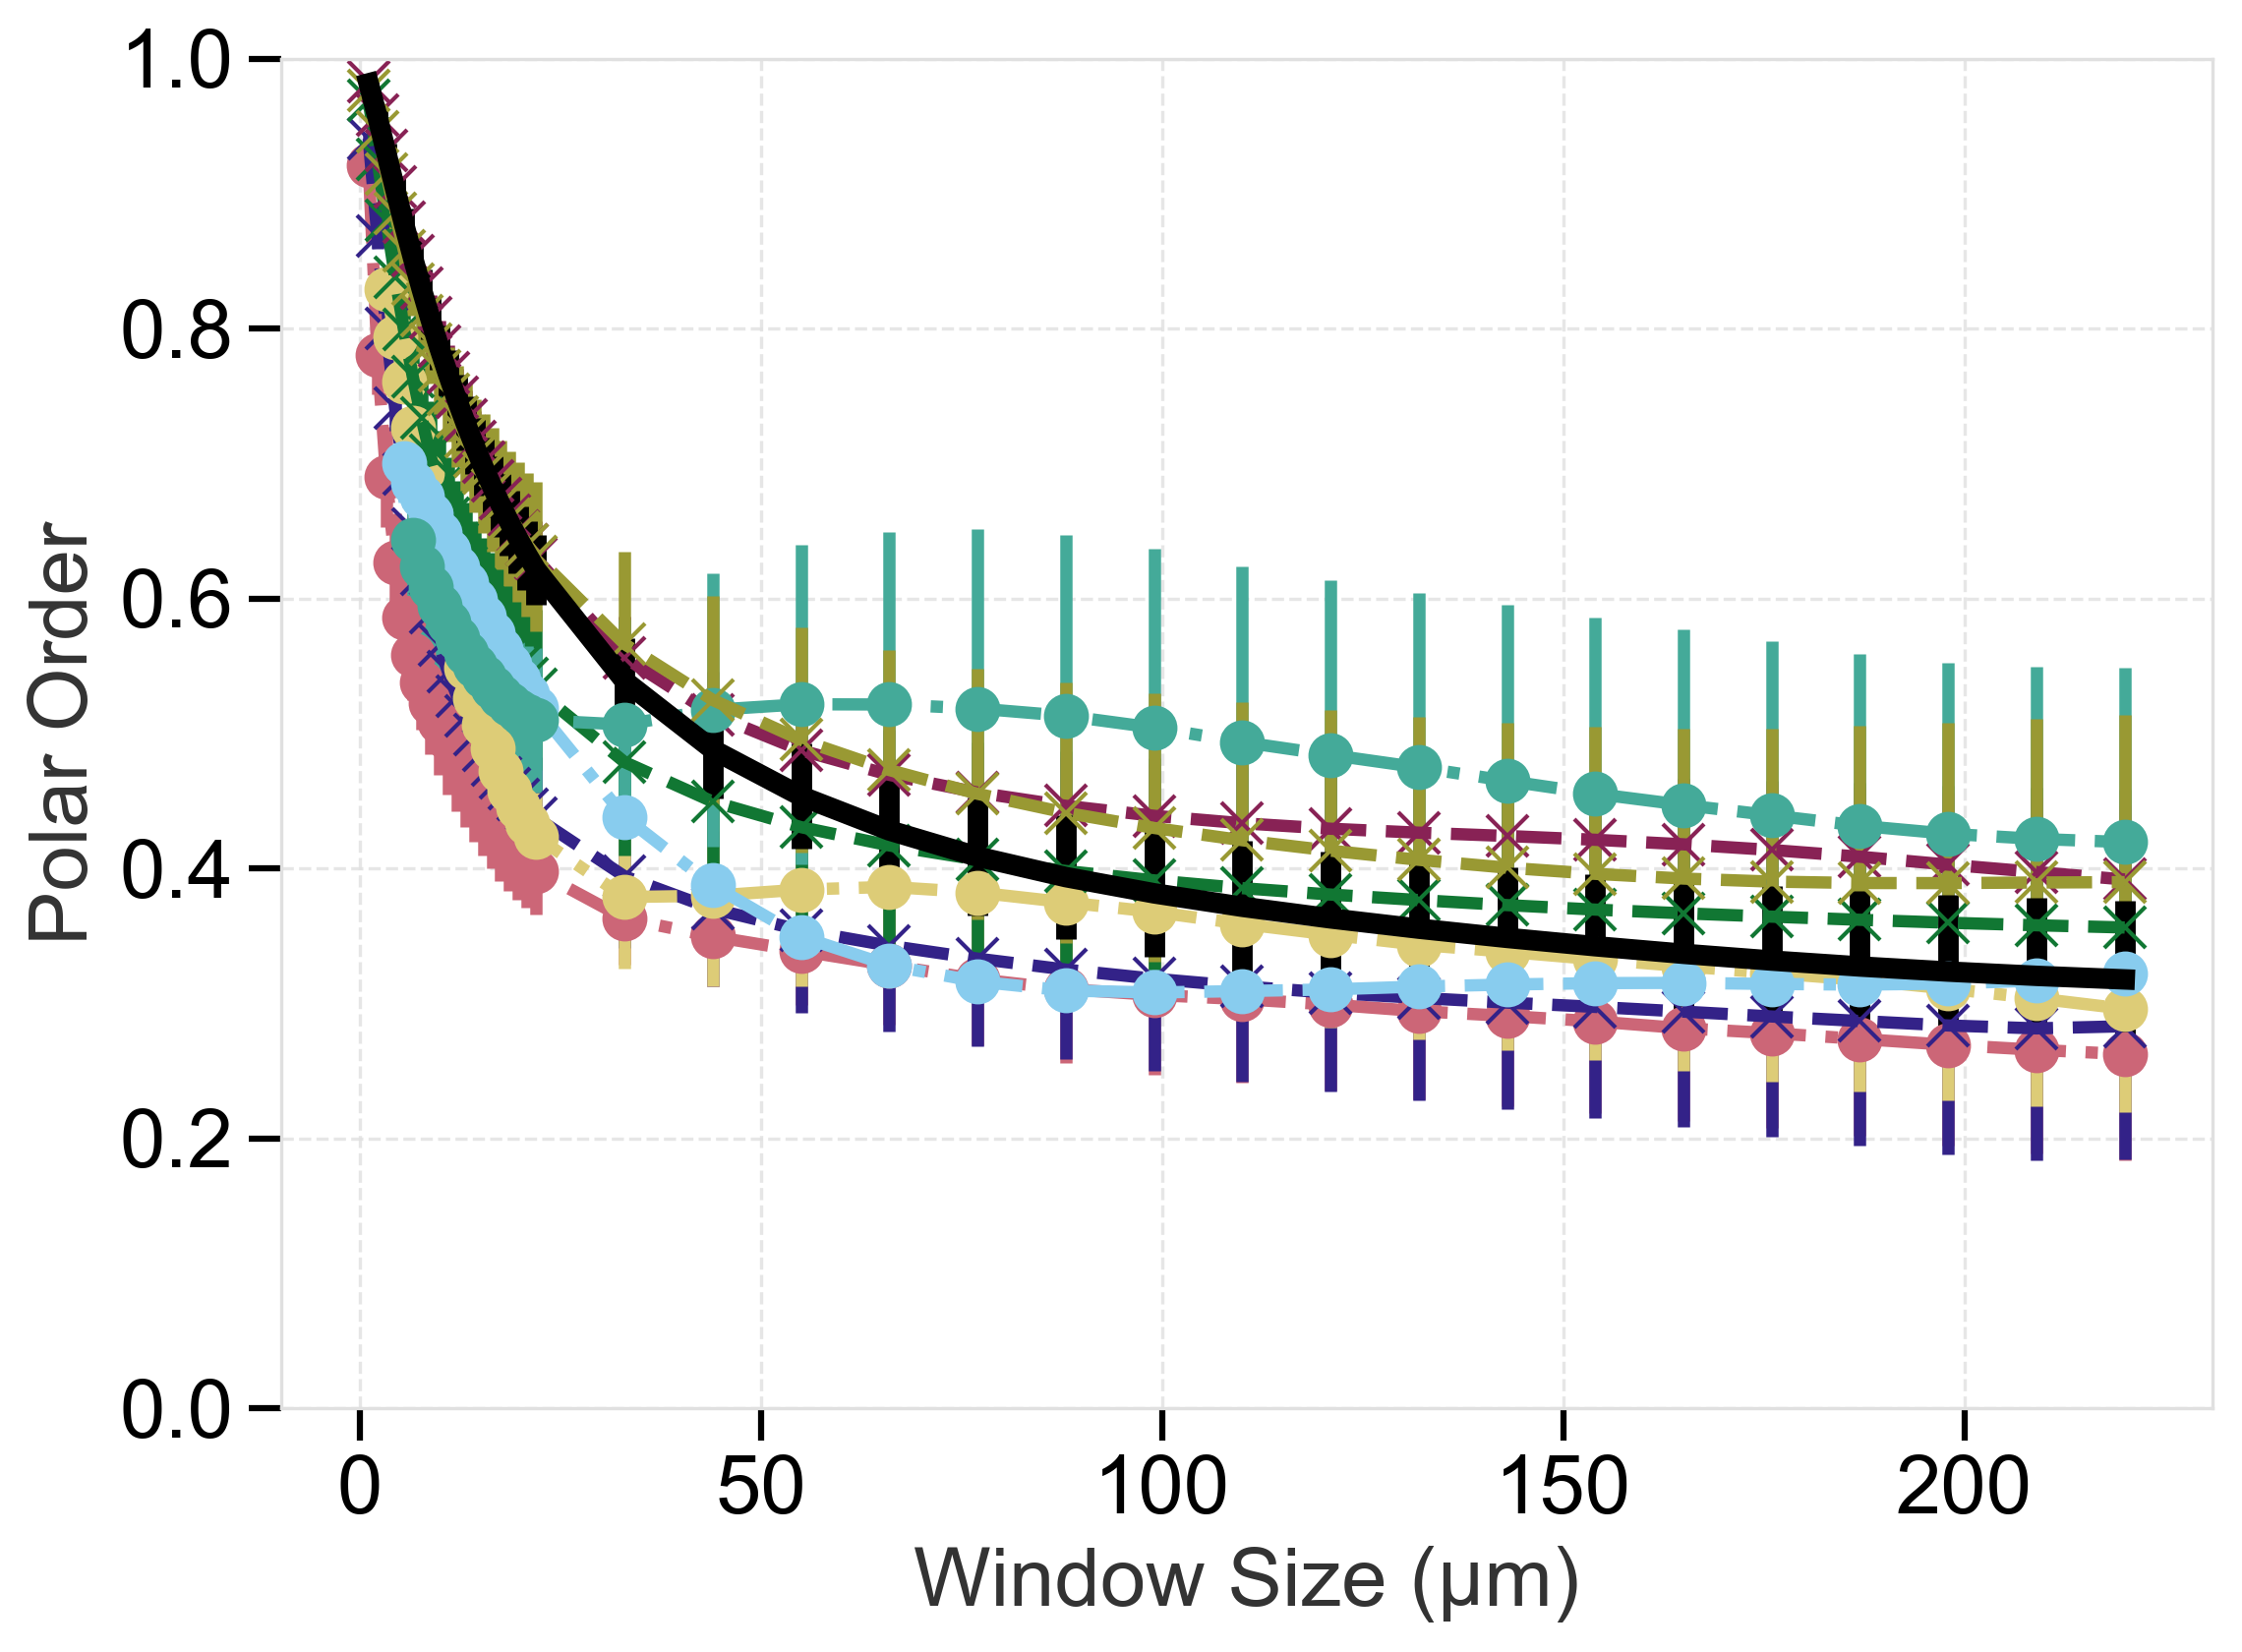

In [26]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar.pdf")

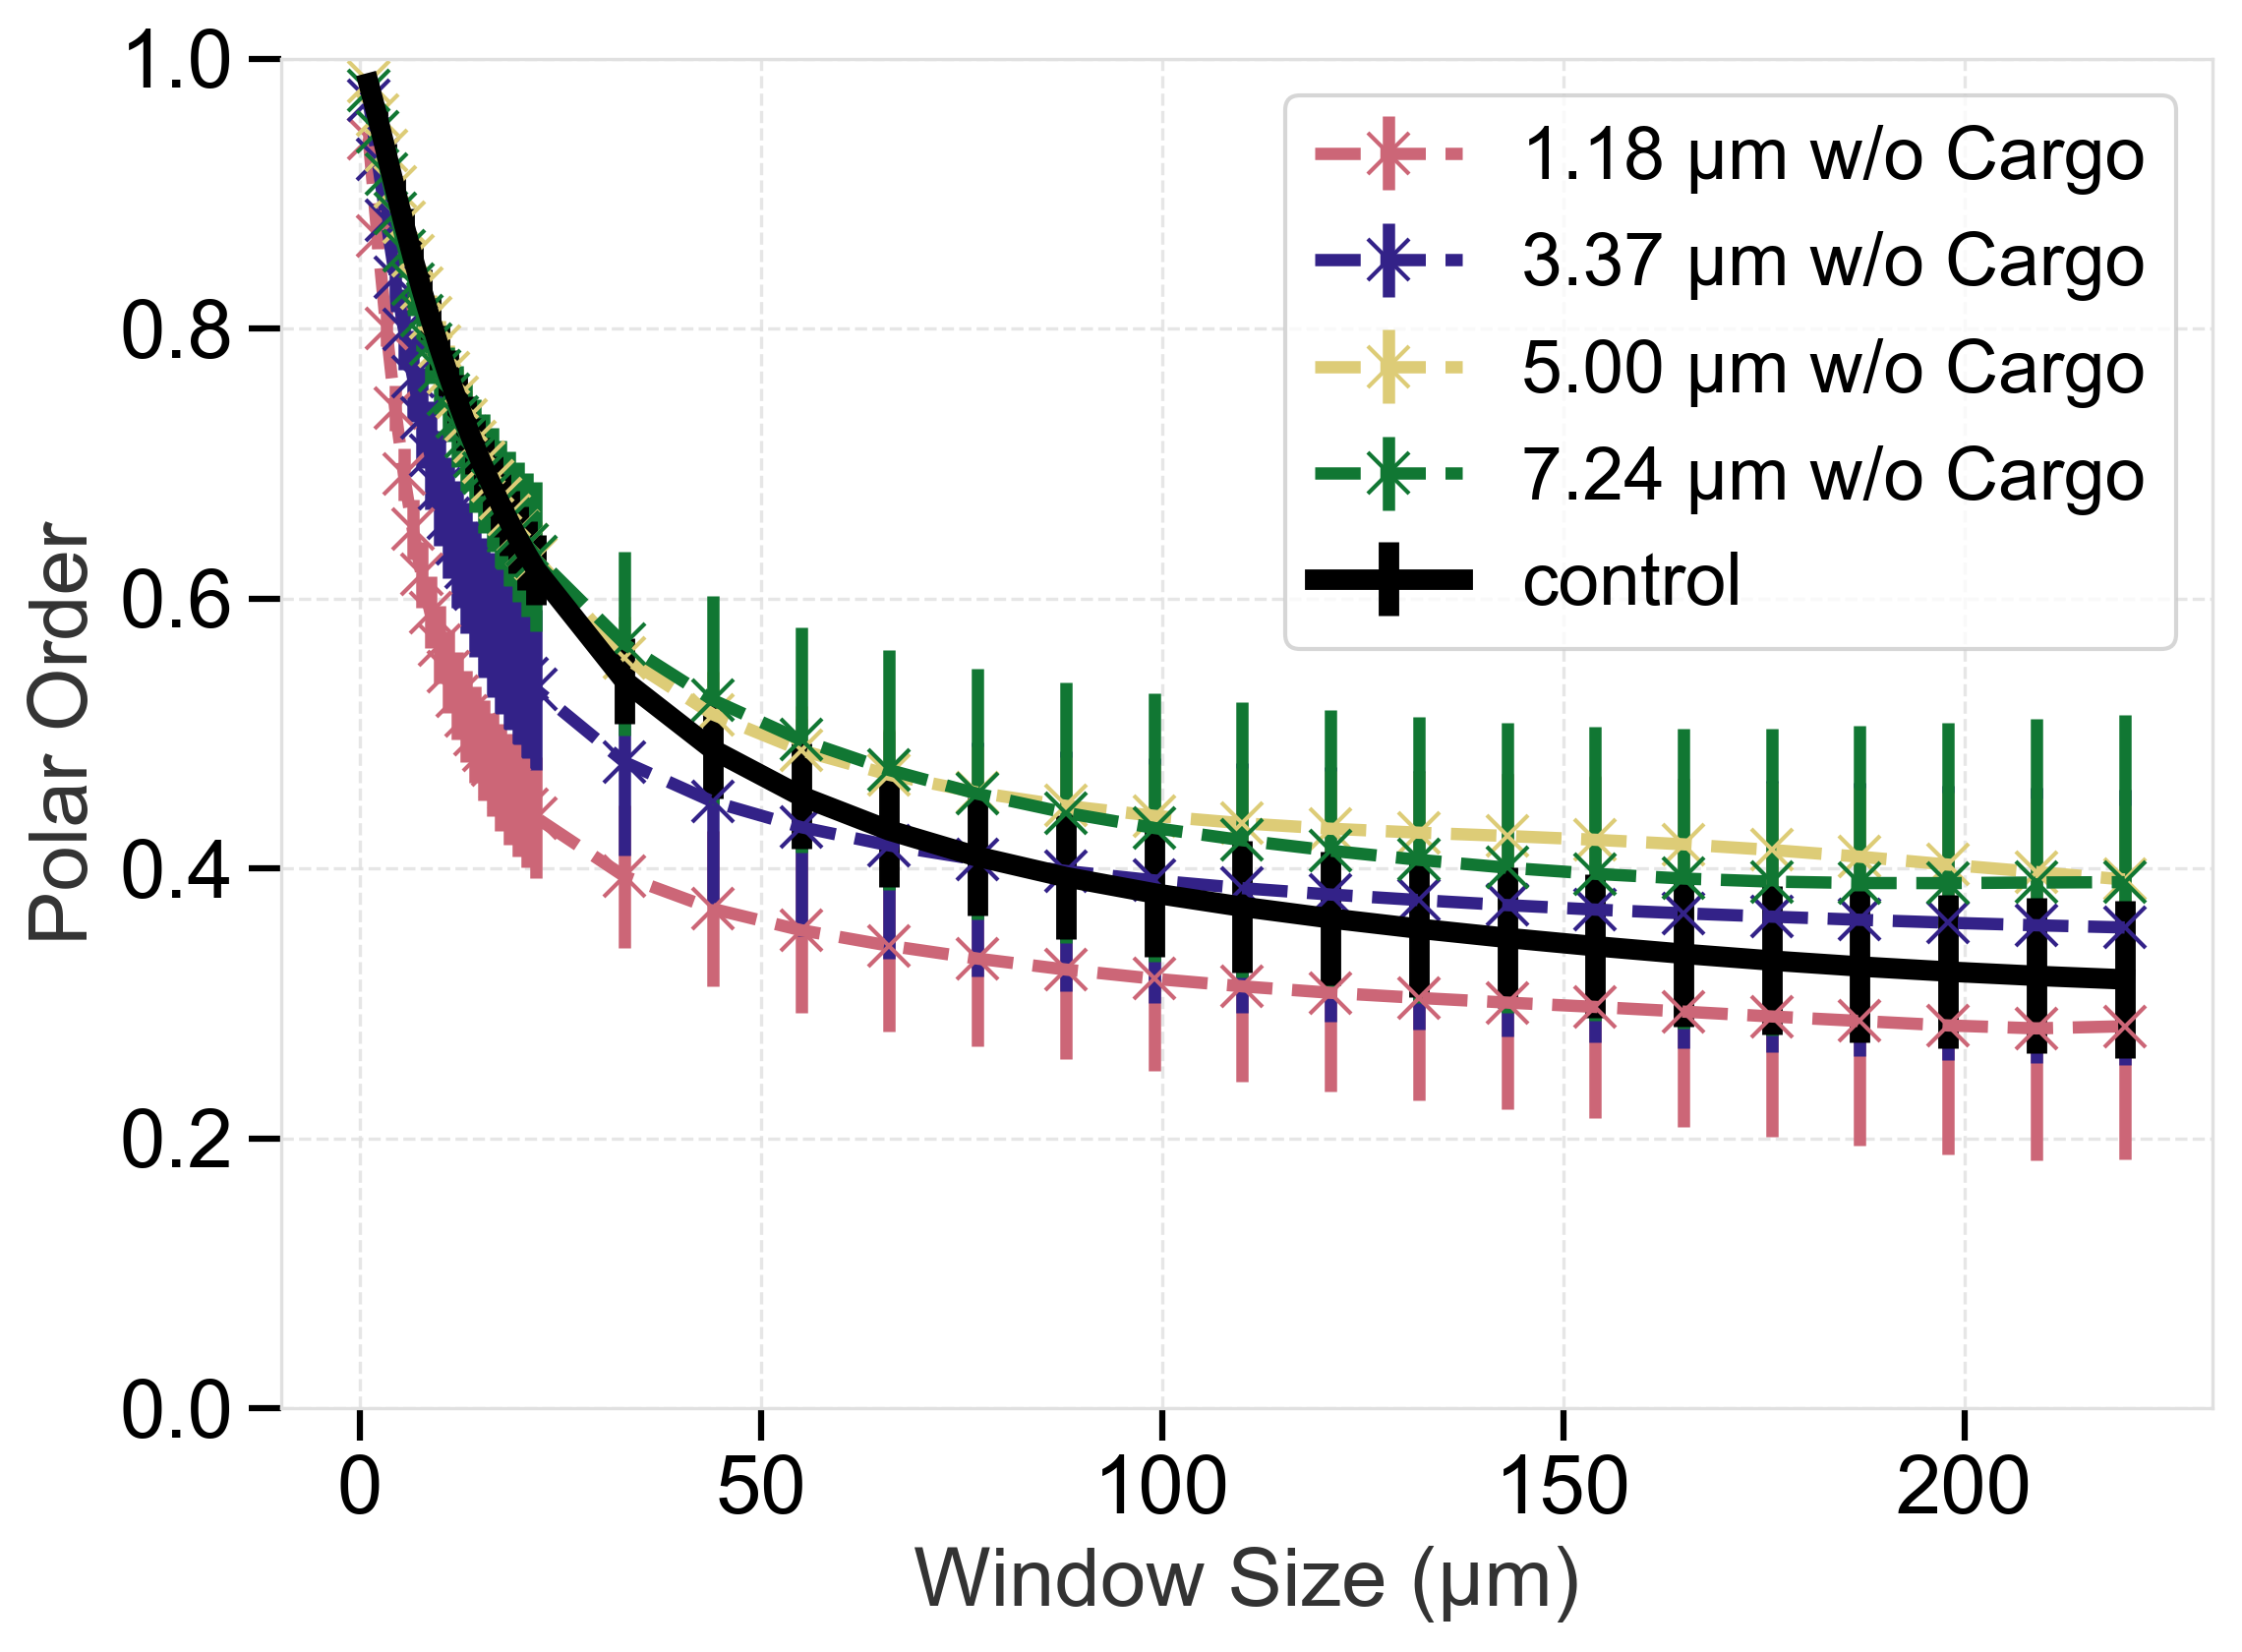

In [29]:
fig, ax = plt.subplots()

plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_wo.pdf")

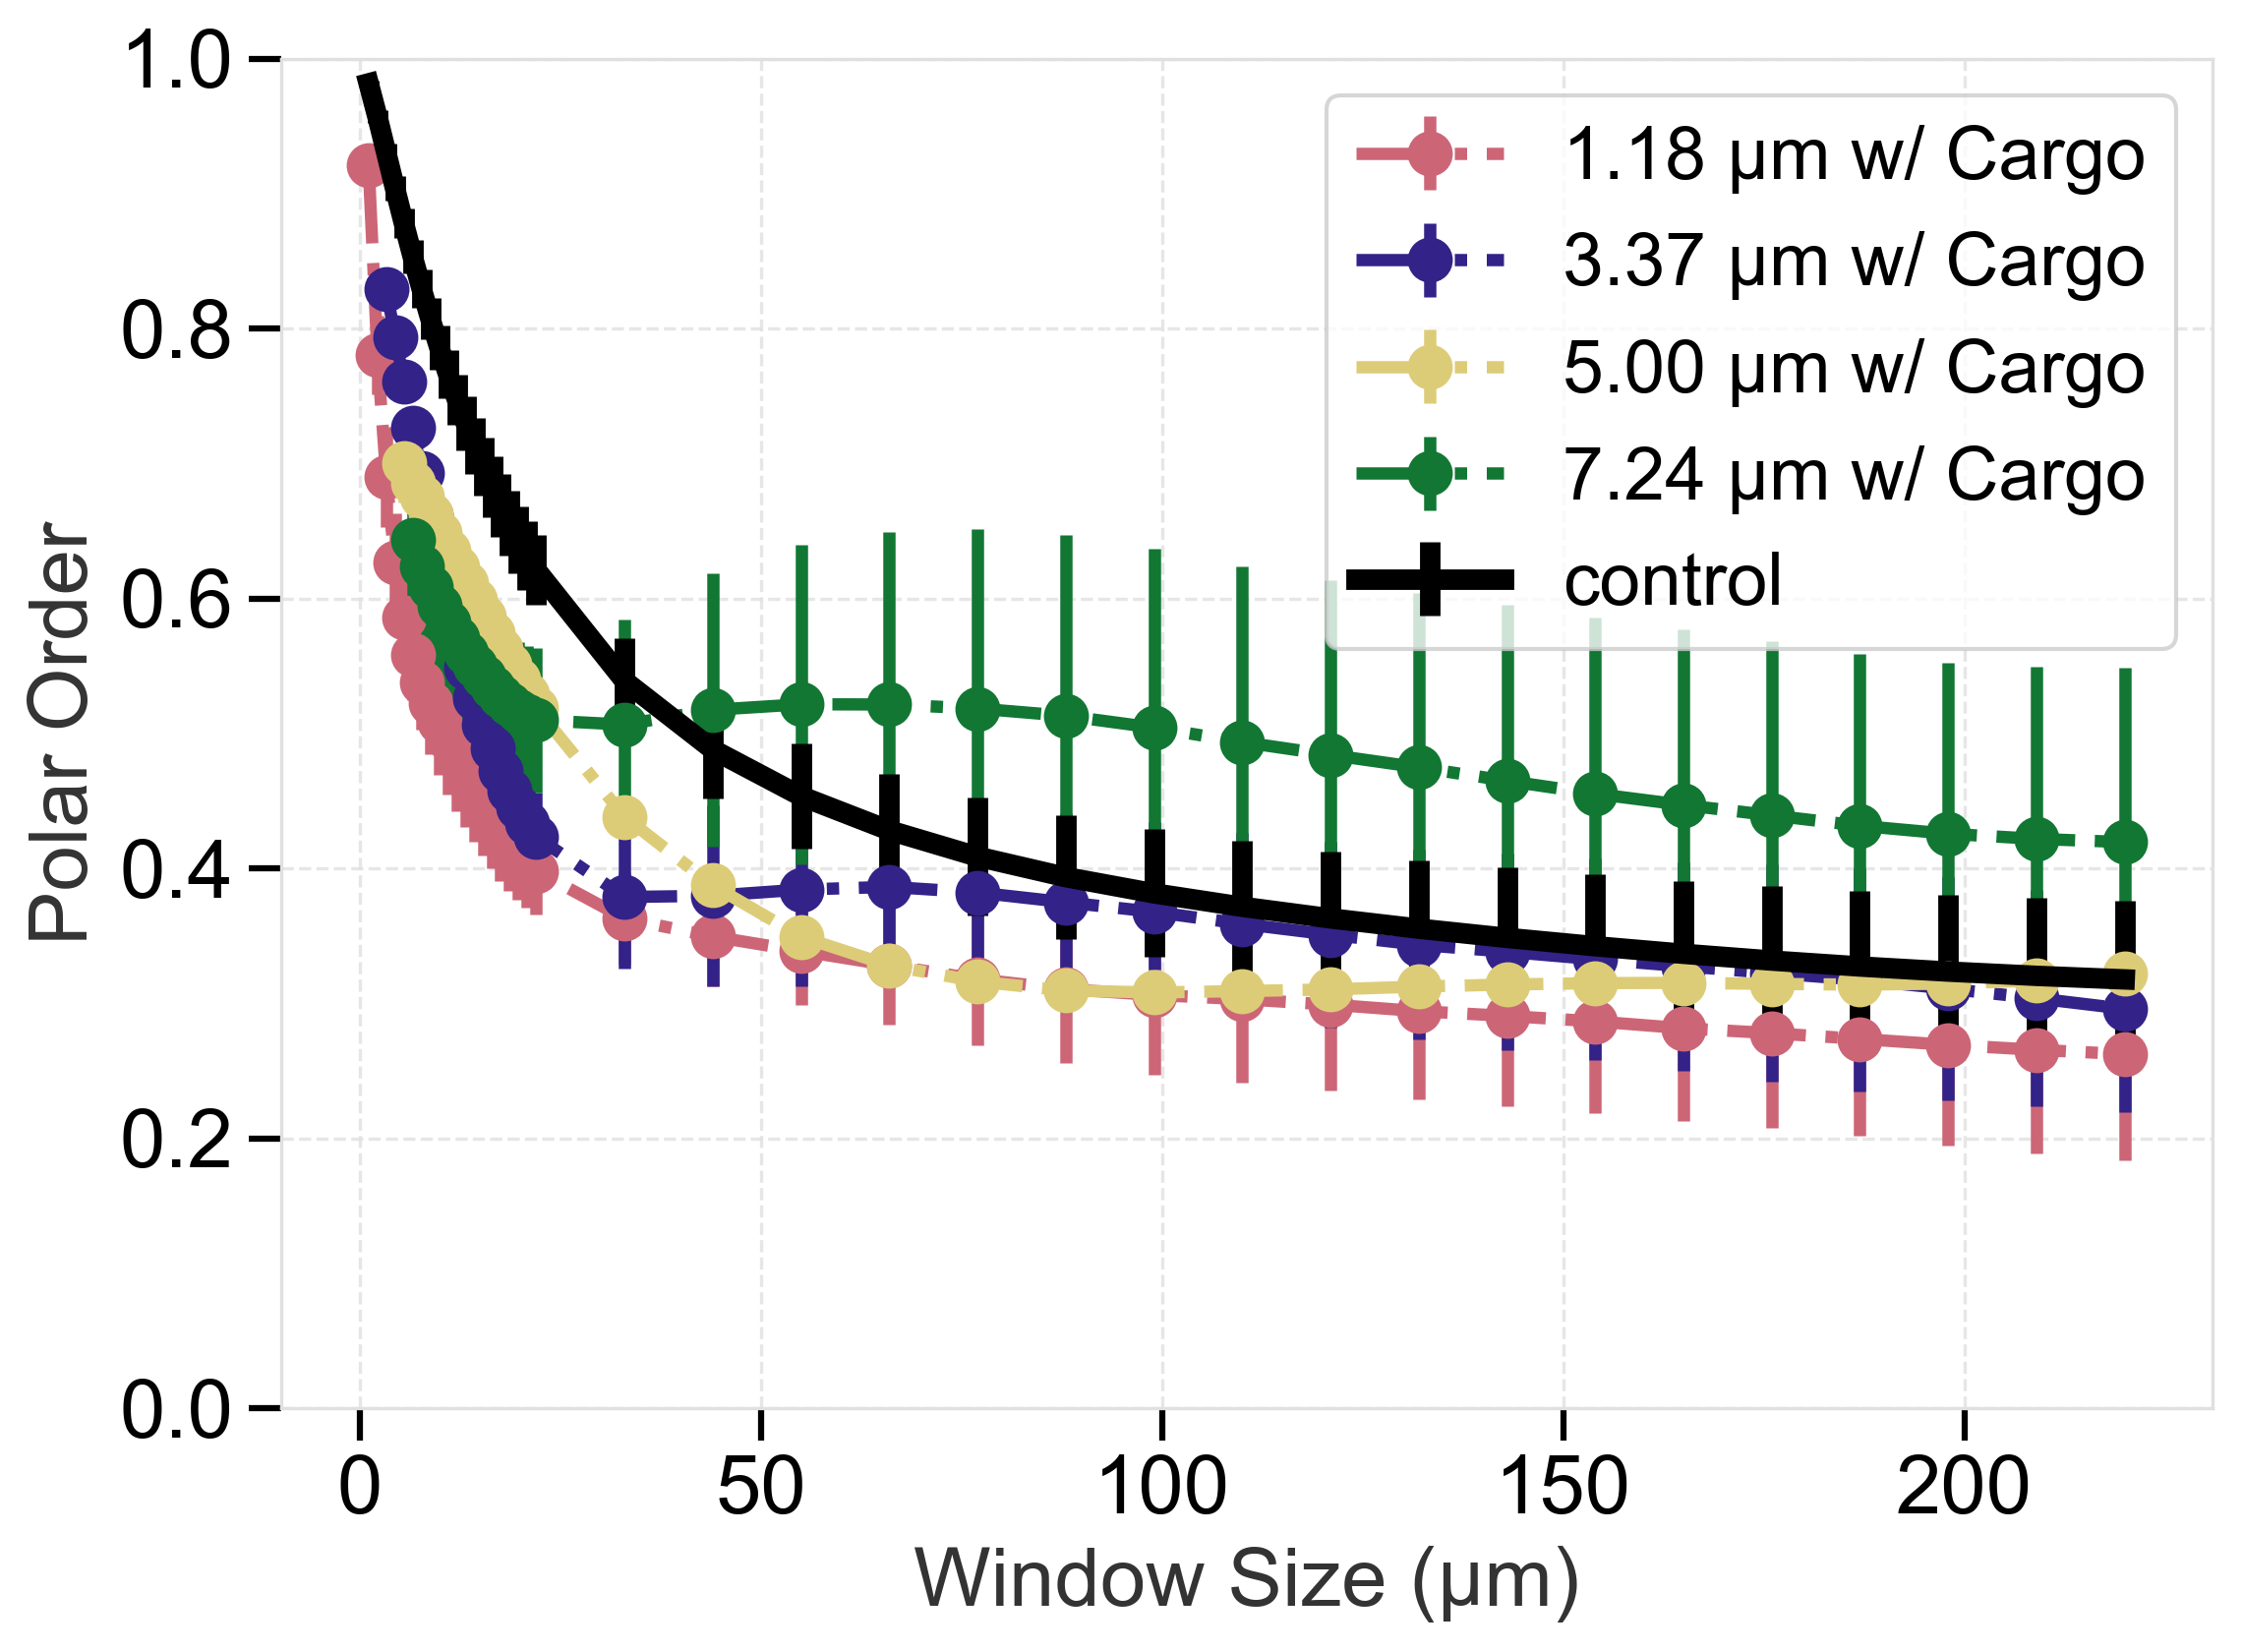

In [30]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_w.pdf")

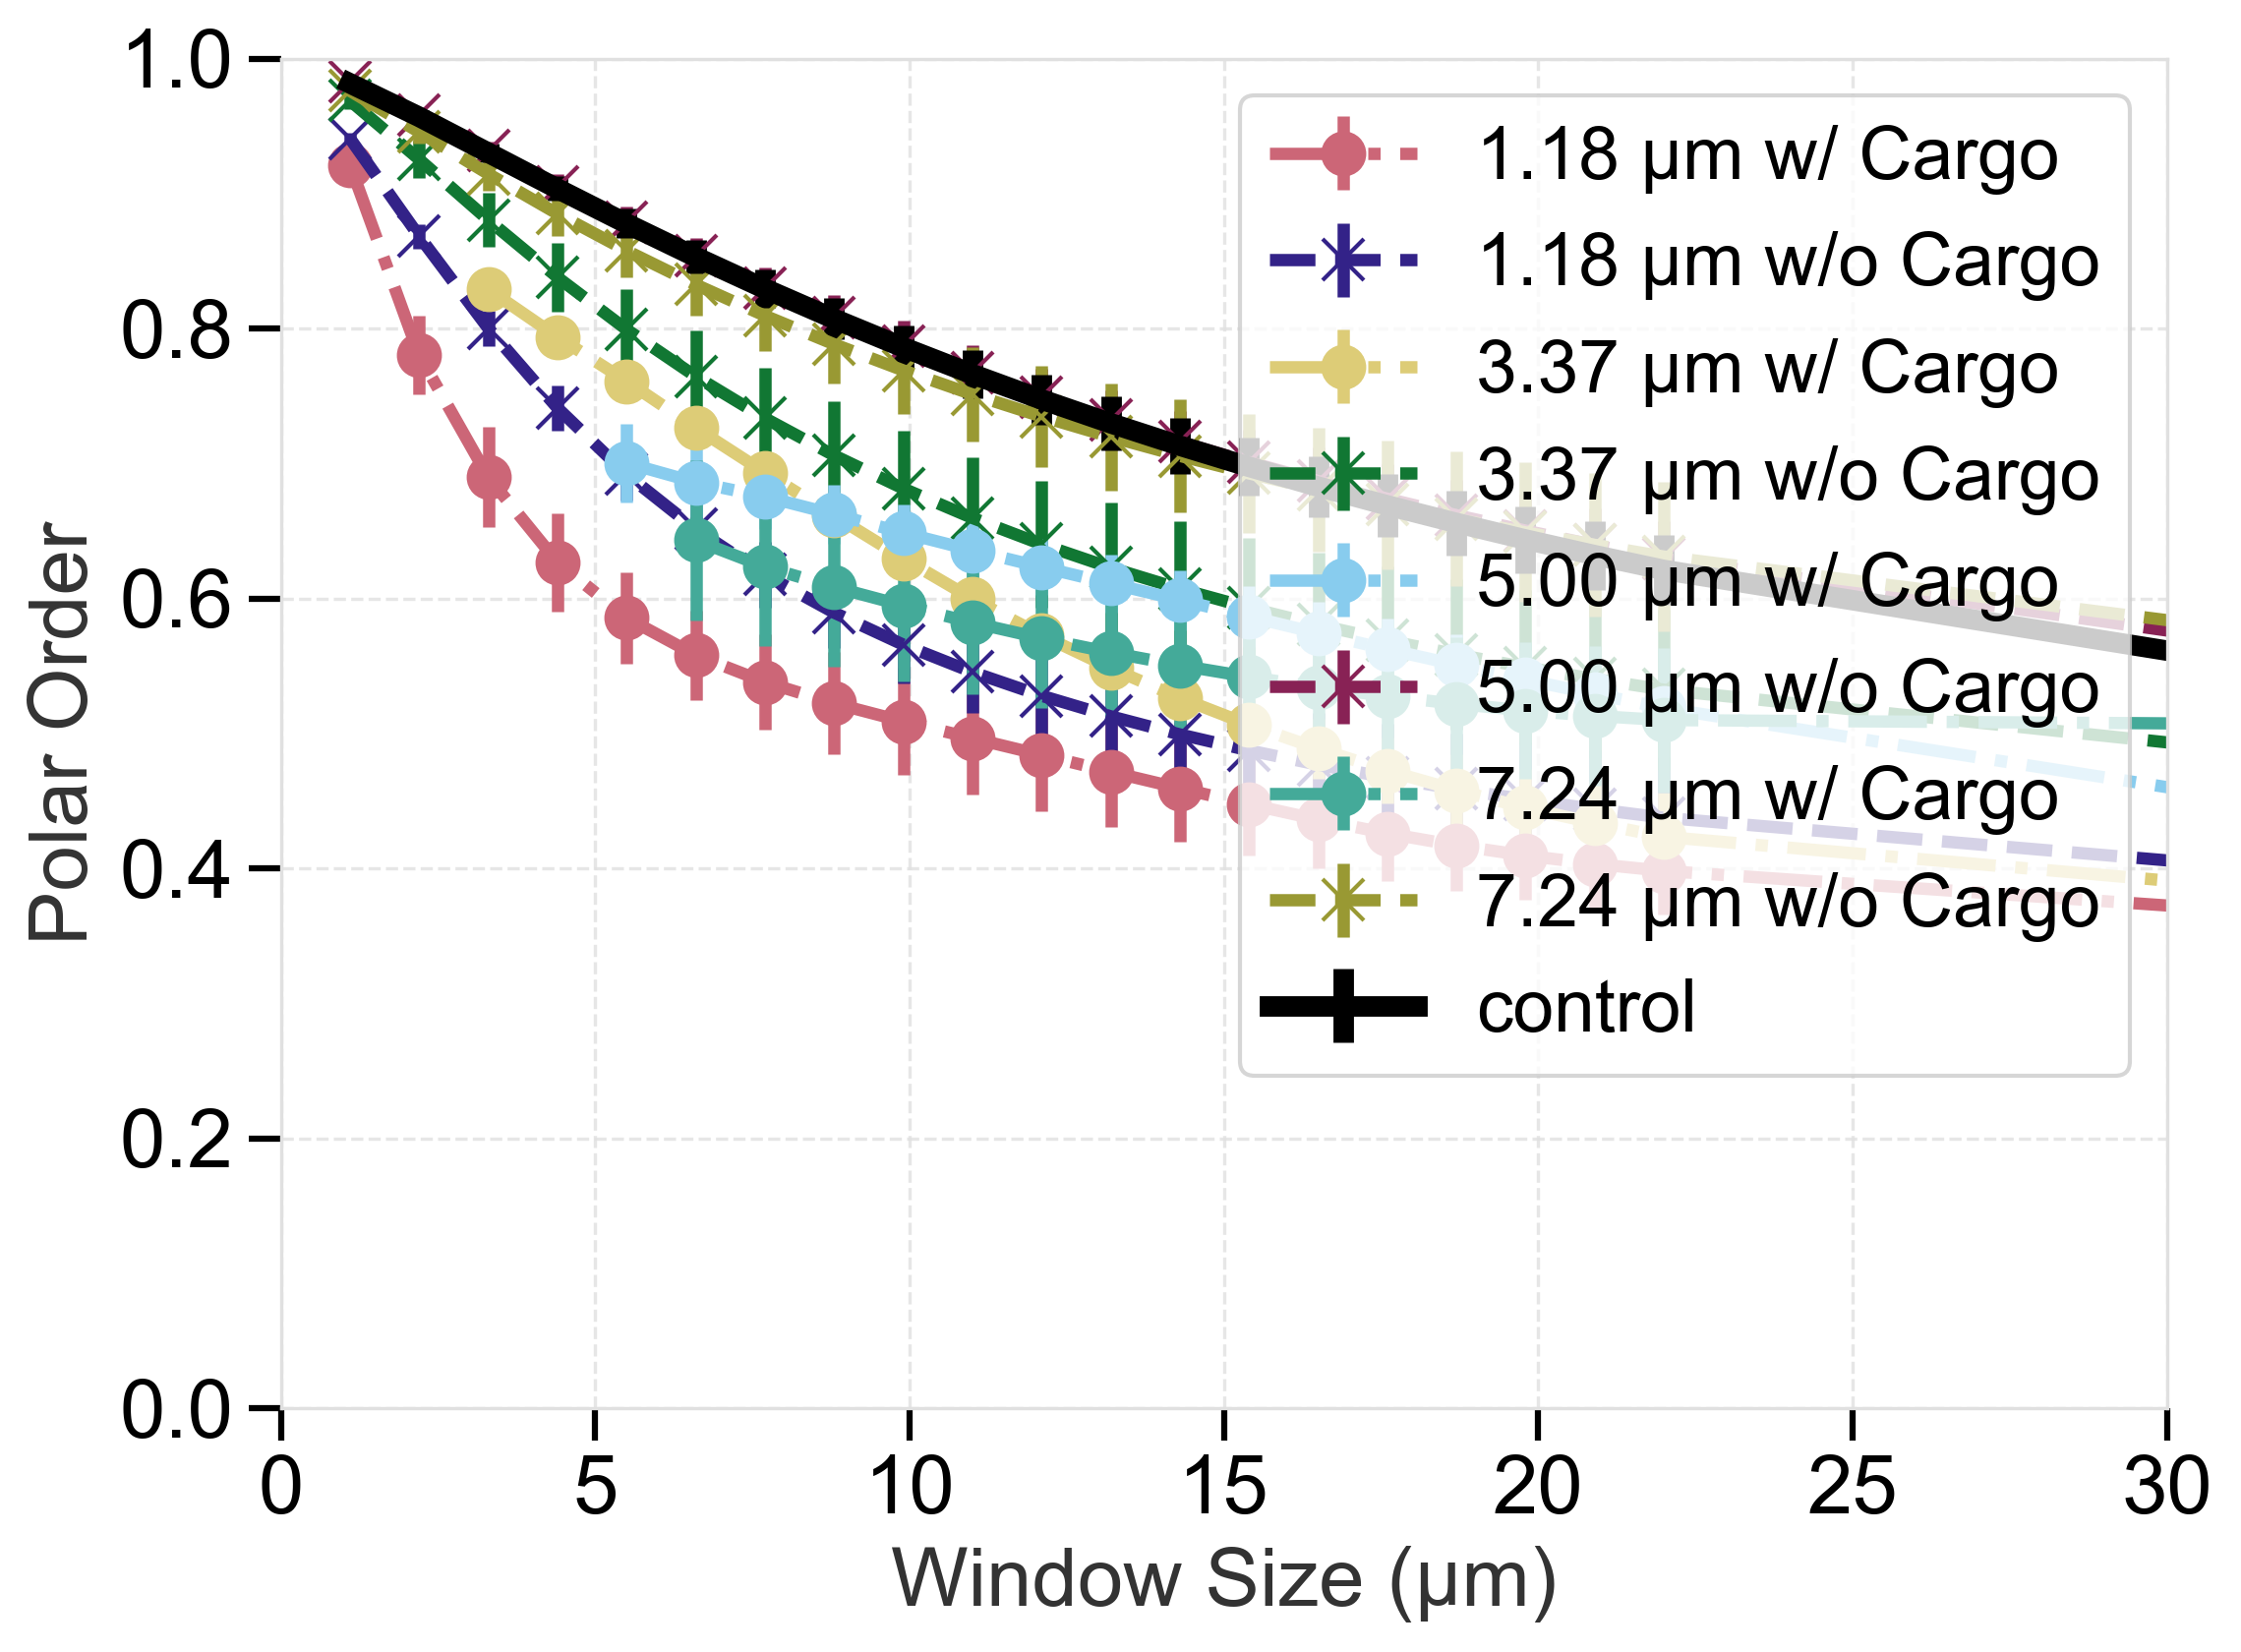

In [31]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)


ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom.pdf")

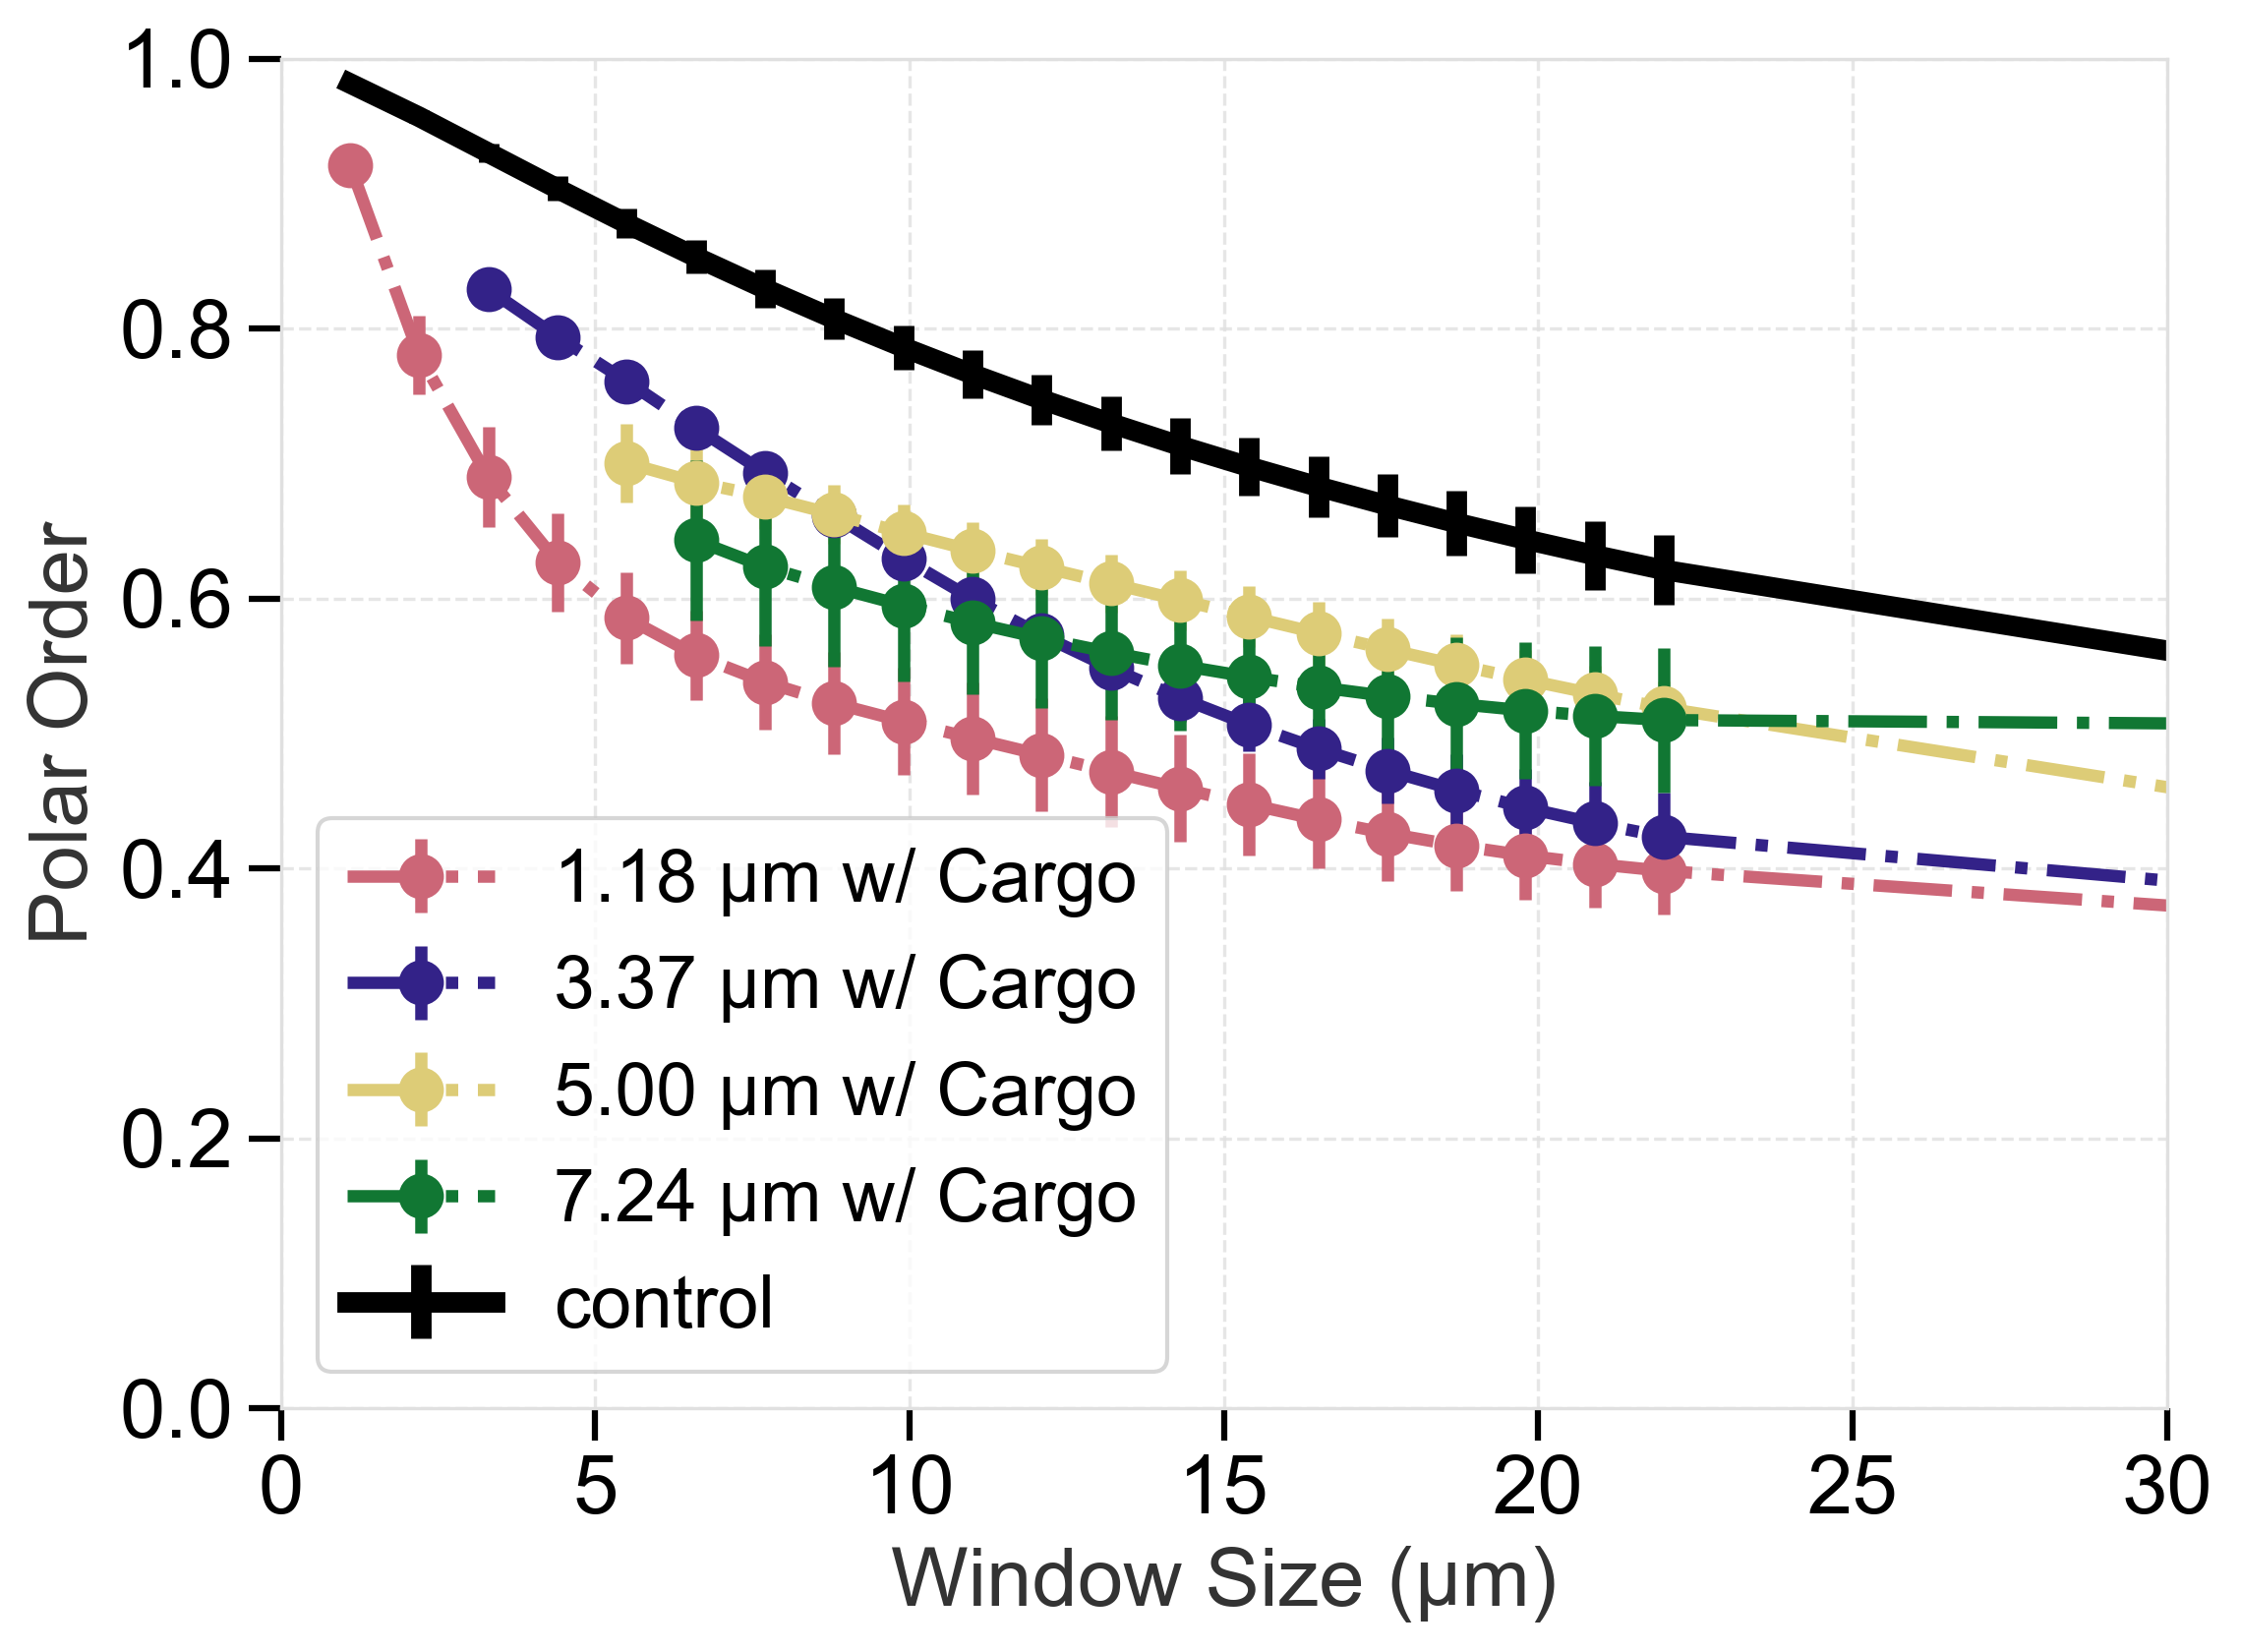

In [32]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_w_zoom.pdf")

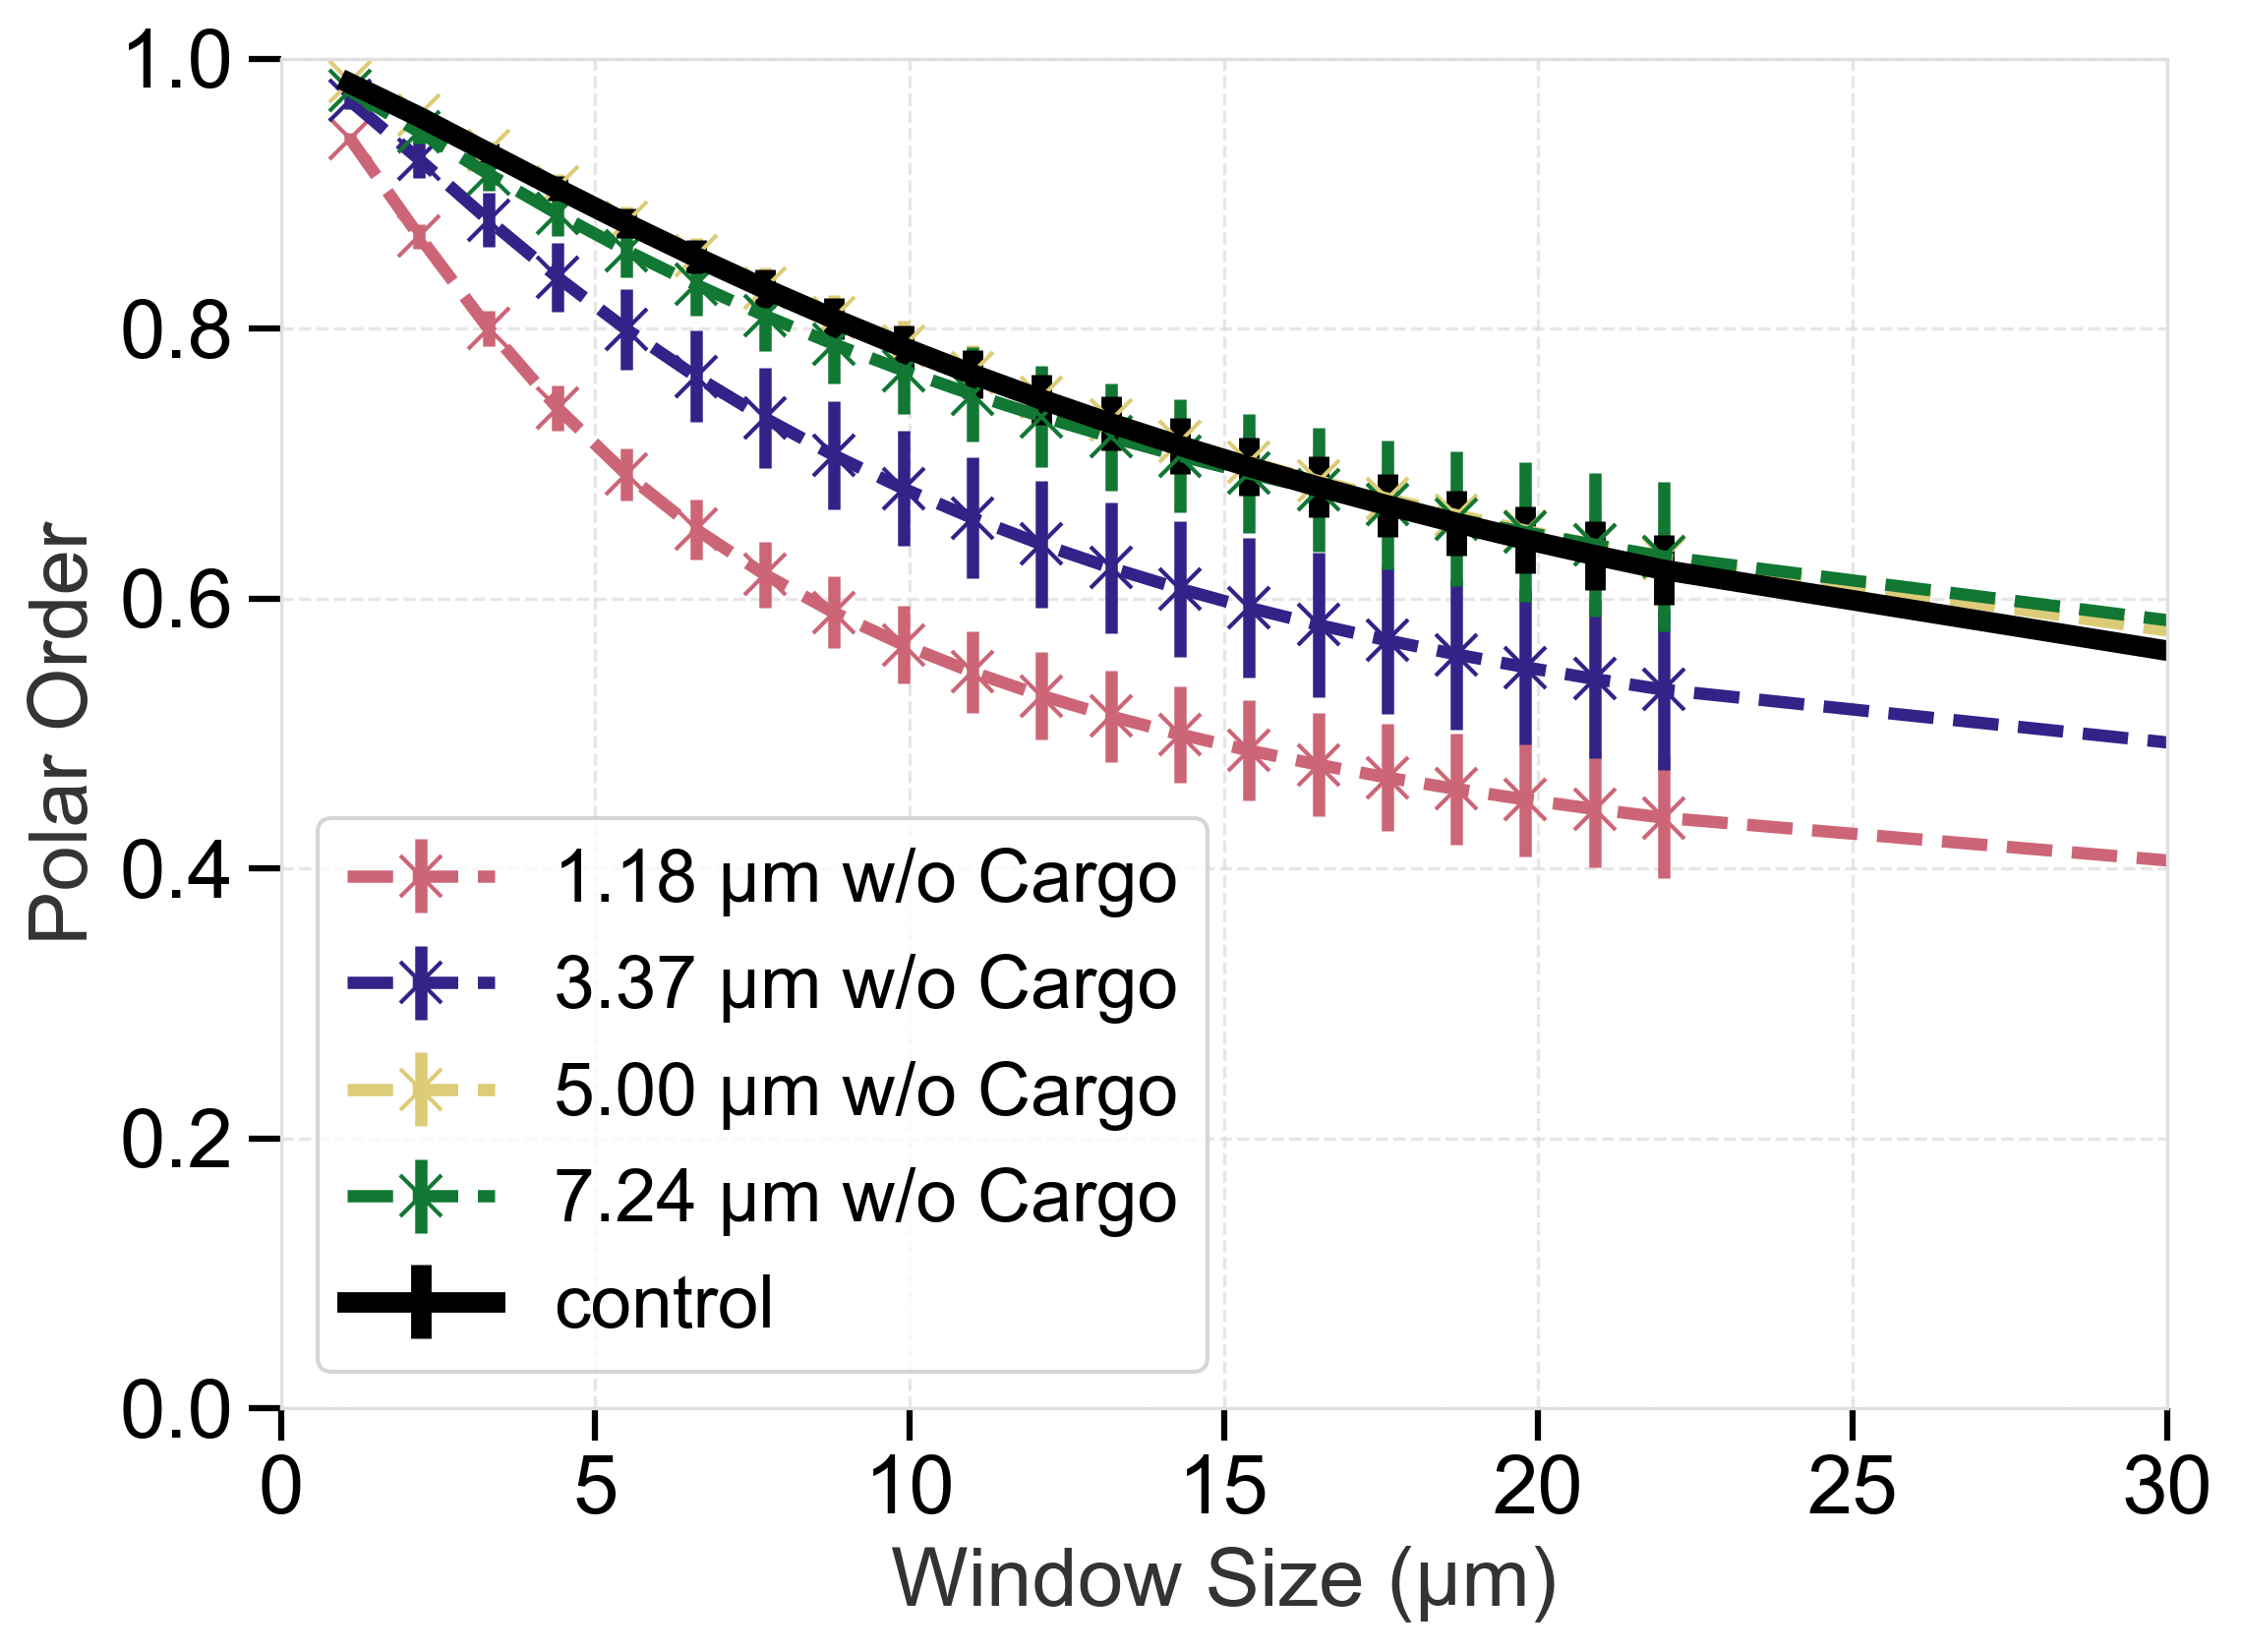

In [33]:
fig, ax = plt.subplots()

plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_wo_zoom.pdf")

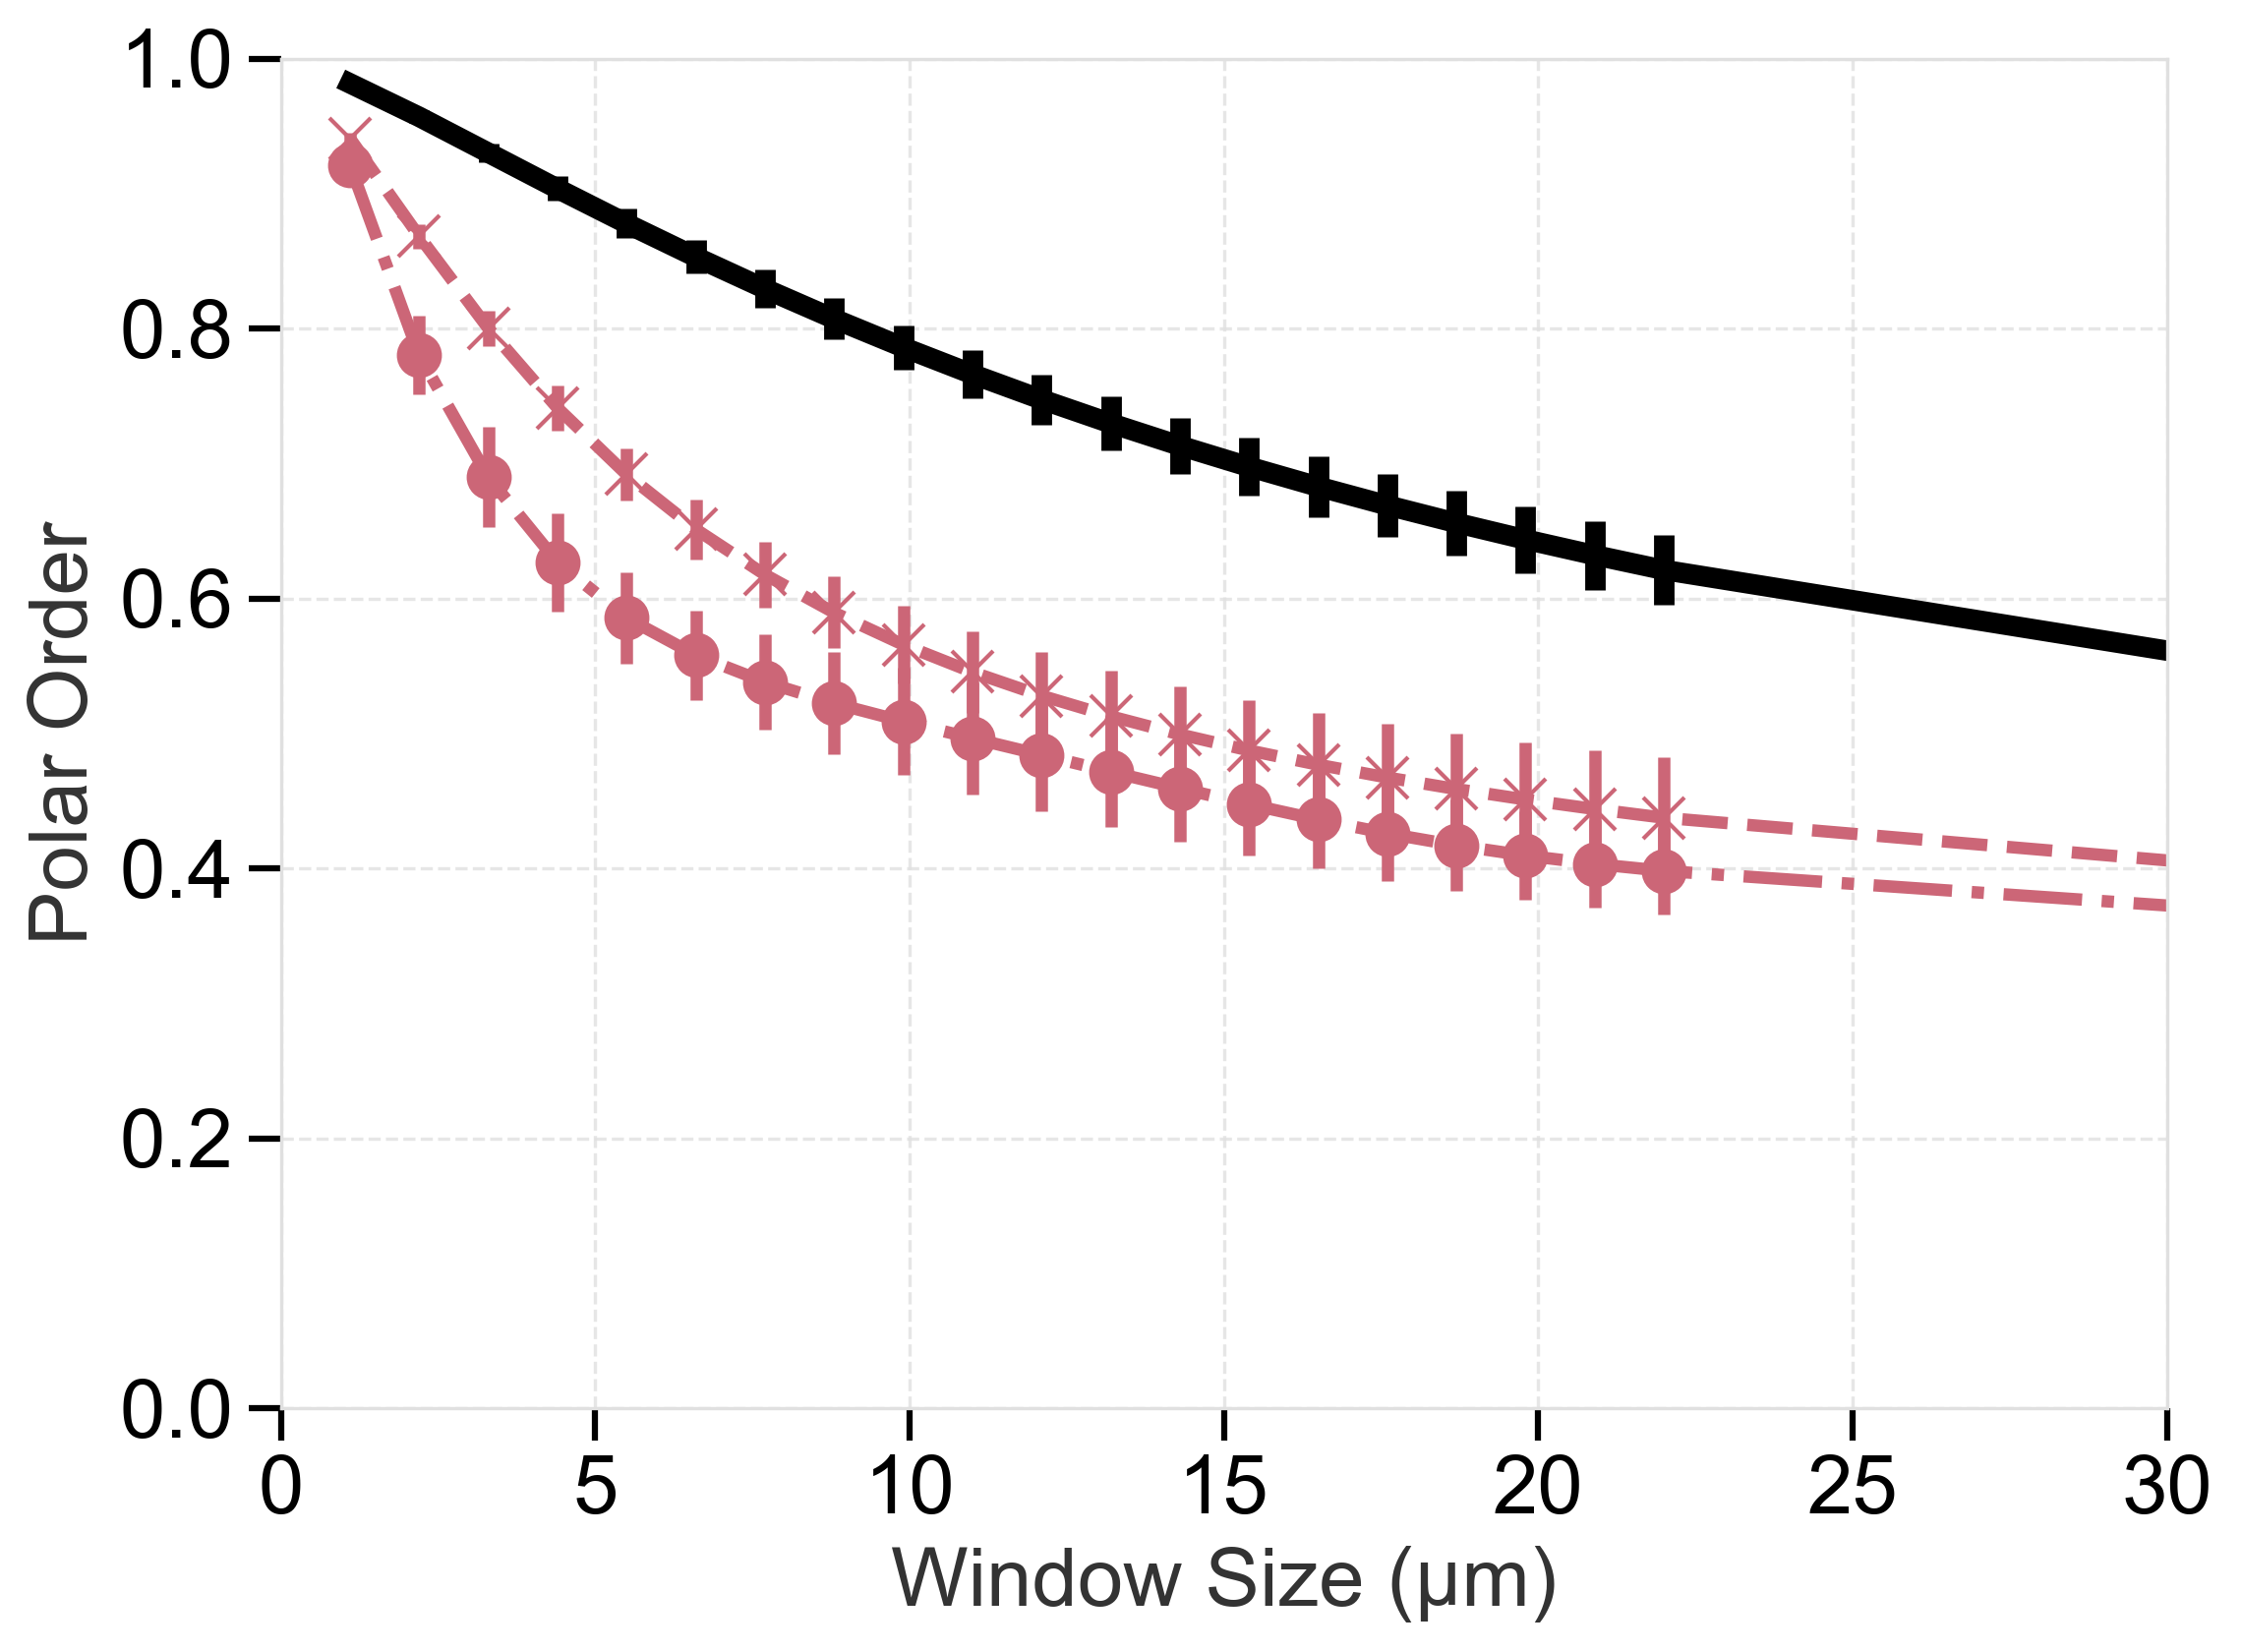

In [34]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[0])
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[0])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_1um.pdf")

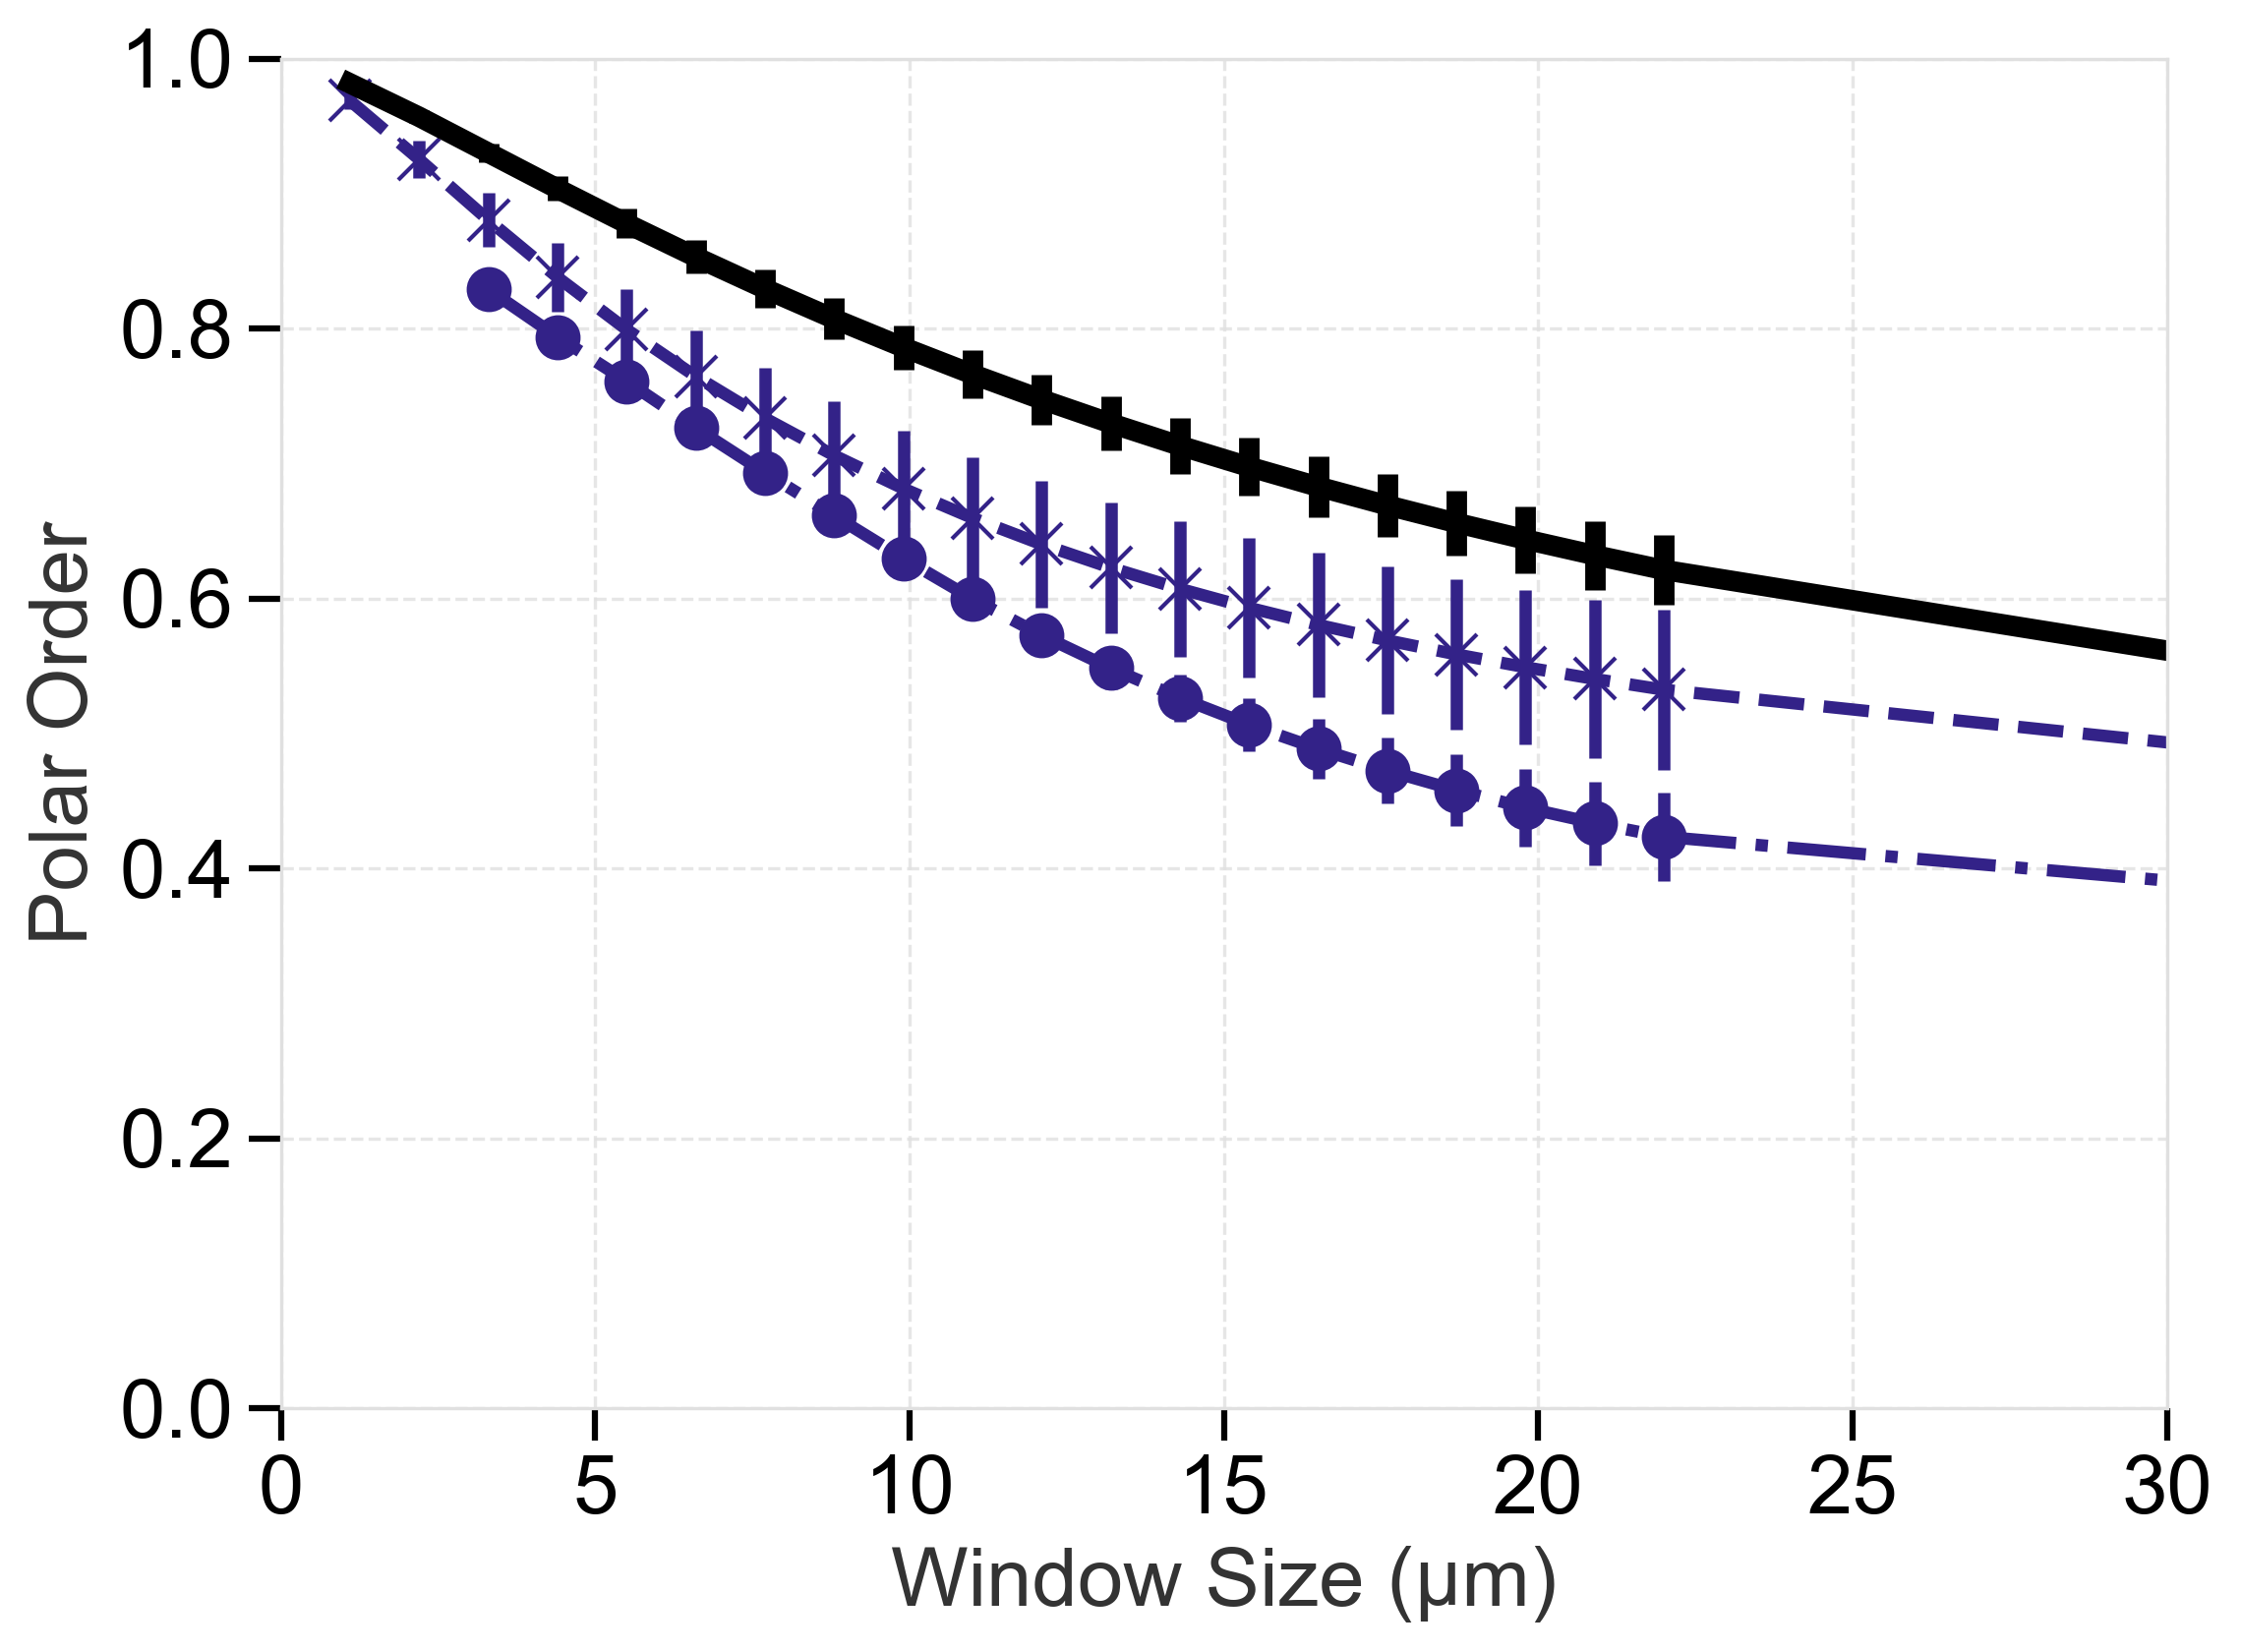

In [35]:
fig, ax = plt.subplots()
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[1])
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[1])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_3um.pdf")

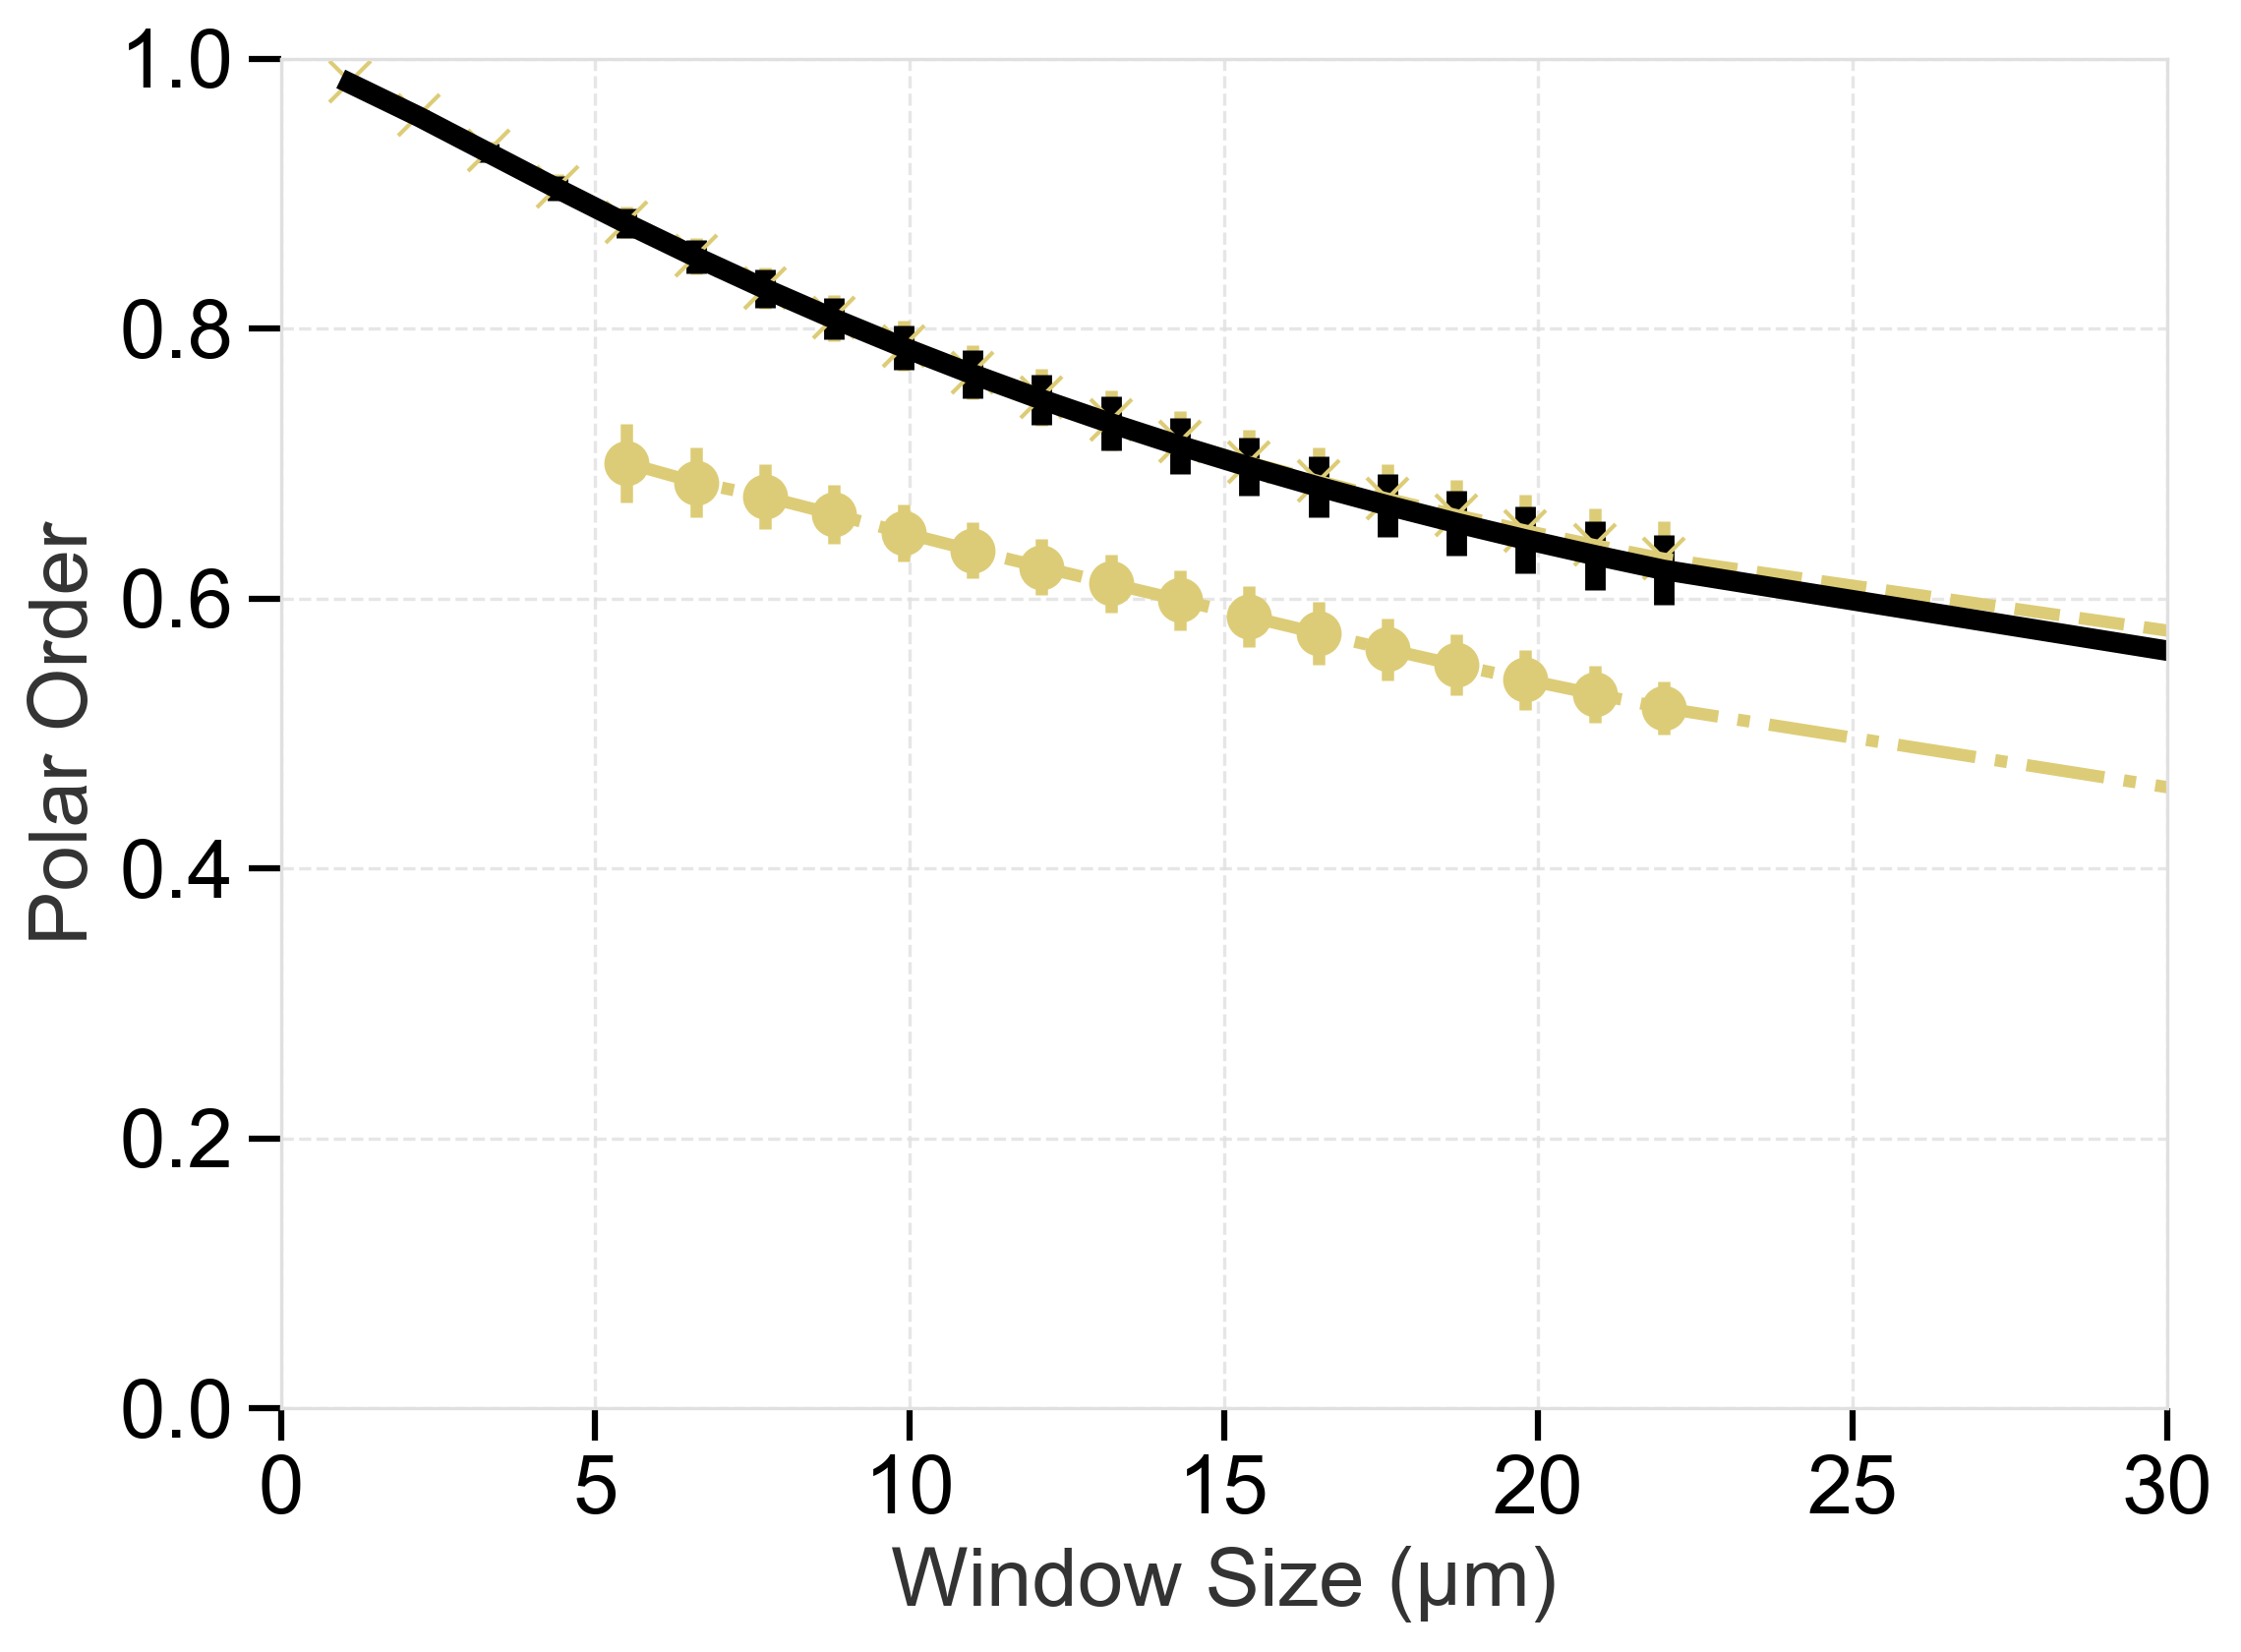

In [36]:
fig, ax = plt.subplots()
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[2])
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[2])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_5um.pdf")

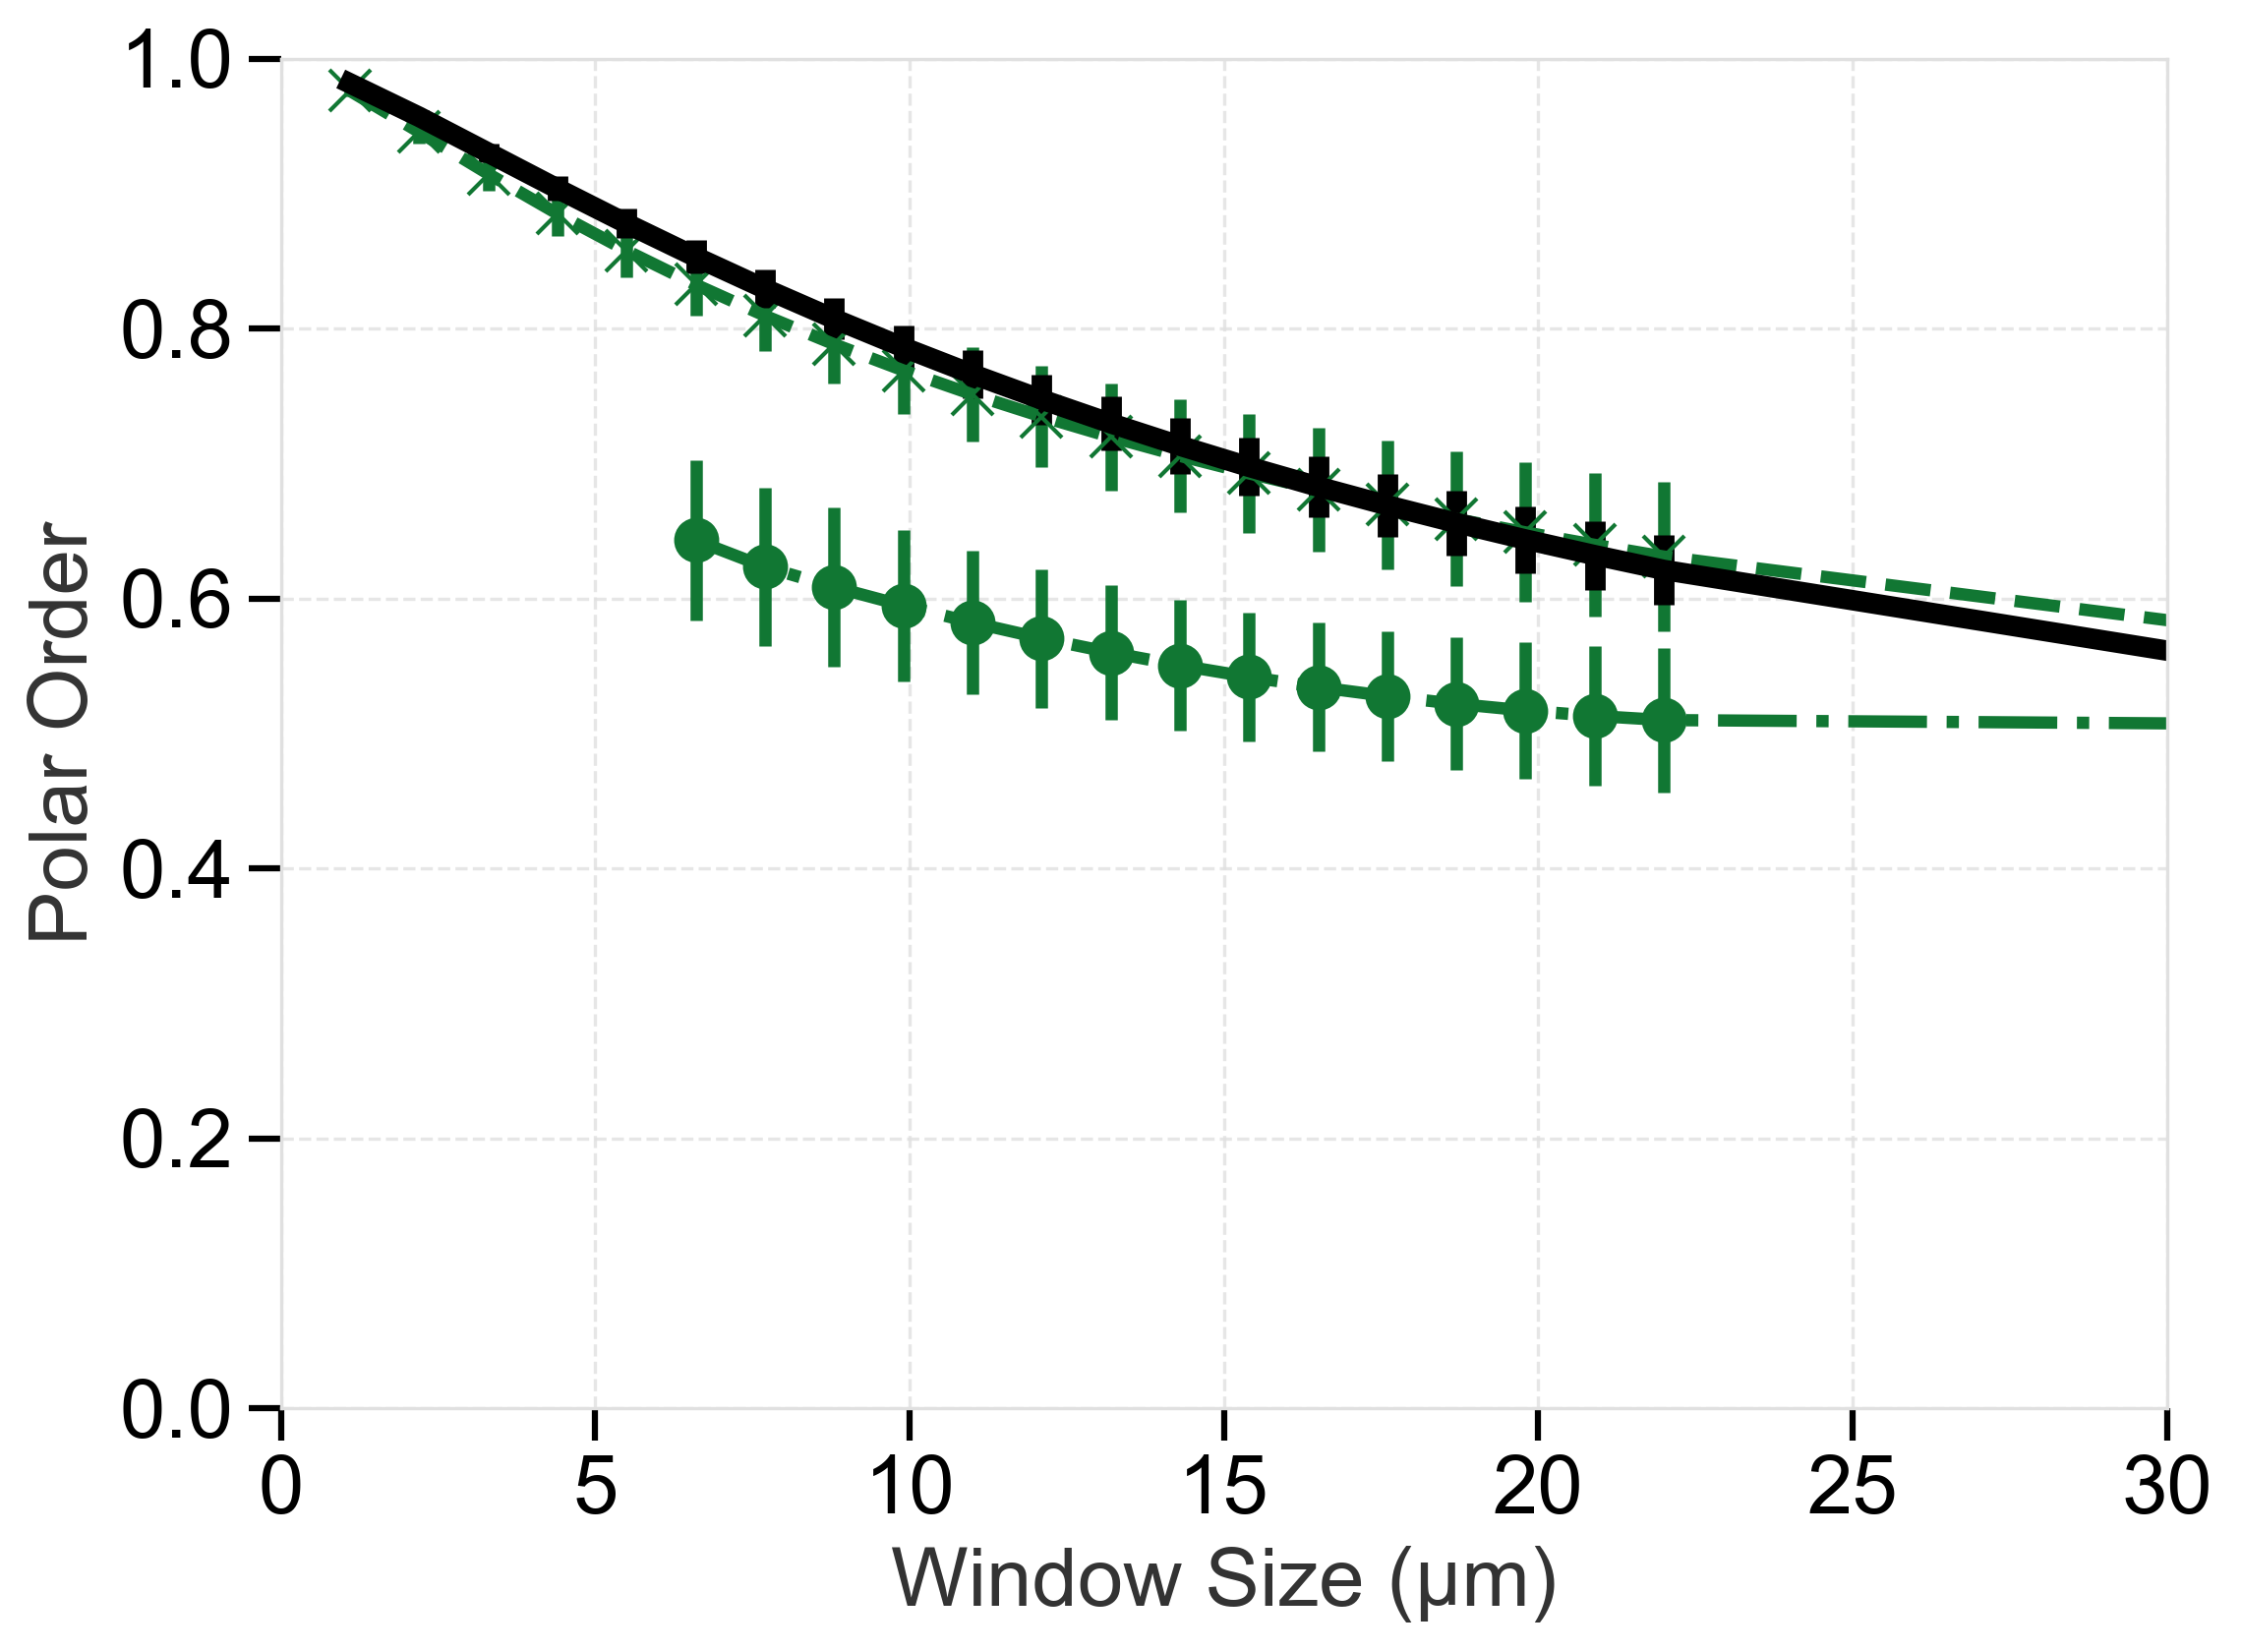

In [37]:
fig, ax = plt.subplots()
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[3])
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[3])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#000000', lw = 5)

ax.set_xlabel('Window Size (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,30)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_7um.pdf")